In [1]:
import math
import numpy as np
import pandas as pd
#from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axisartist.axislines import SubplotZero
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

dx = sin(x)dt + dW

dx = f(x,t)dt + g(x,t)dW

x - random process

f(x,t) = sin(x)

g(x,t) - stochastic function = 1

dW - Wiener process increment





In [2]:
def noise_psd(N, psd = lambda f: 1):
        X_white = np.fft.rfft(np.random.randn(N));
        S = psd(np.fft.rfftfreq(N))
        # Normalize S
        S = S / np.sqrt(np.mean(S**2))
        X_shaped = X_white * S;
        return np.fft.irfft(X_shaped);

def PSDGenerator(f):
    return lambda N: noise_psd(N, f)

@PSDGenerator
def white_noise(f):
    return 1;

@PSDGenerator
def blue_noise(f):
    return np.sqrt(f);

@PSDGenerator
def violet_noise(f):
    return f;

@PSDGenerator
def brownian_noise(f):
    return 1/np.where(f == 0, float('inf'), f)

@PSDGenerator
def pink_noise(f):
    return 1/np.where(f == 0, float('inf'), np.sqrt(f))

In [3]:
class Binary_Telegraph_Process:
    """
    Инициализация телеграфного процесса
    :param size: размер выборки
    :param f: функция ошибки
    :param p1: матожидание ошибки в случае np.random.normal, low в случае np.random.uniform, alpha в случае np.random.beta
    :param p2: дисперсия ошибки в случае np.random.normal, high в случае np.random.uniform, beta в случае np.random.beta
    """

    def __init__(self, size, f, p1=None, p2=None, p3=None, RANDOM_SEED=1234, no_error=False):
        self.size = size
        self.f    = f
        self.p1   = p1
        self.p2   = p2
        self.p3   = p3
        self.D   = D
        self.RANDOM_SEED   = RANDOM_SEED
        self.no_error = no_error

    def errors(self):
        if self.p1 == 'ECG':
            dir_ = 'sample_2.csv'
            #no file full_ecg.csv
            return pd.read_csv(dir_)["X"].values[::24]
        else:
            if self.p1 == None:
                return self.f
            elif self.p2 == None:
                return self.f(self.p1, size=self.size)
            elif self.p3 == None:
                return self.f(self.p1, self.p2, self.size)
            else:
                return self.f(self.p1, self.p2, self.p3, self.size)

    def p_hit(self, x_0, x_h, x_b = math.pi, dt  = 1, D = 0.5):

      # dx(t) = f(x(t))dt + g(x(t))dW(t), where g(x) = sqrt(2*D), D - diffusion term


      term1 = -np.cos(x_b) / (2 * D * (np.exp(2 * dt * np.cos(x_b)) - 1))
      term2 = (x_h - x_b + (x_0 - x_b) * (np.exp(dt * np.cos(x_b))) - (np.sin(x_b) / np.cos(x_b)))**2
      term3 = 1 / (4 * D * dt) * (x_h - (x_0 + dt * (np.sin(x_0) + np.sin(dt)) / 2))**2

      P_hit = np.exp(term1 * term2 + term3)

      return P_hit


    def get_data(self, delt_t, D):
        components = pd.DataFrame()
        np.random.seed(self.RANDOM_SEED)
        data = []
        D = D
        i = 0
        x_t = np.pi/1e6
        data.append(x_t)
        sin_x = []
        sin_x.append(math.sin(x_t))
        error_part = [0]


        dt = delt_t


        errors = self.errors()
        #errors = pd.read_csv('sample_29.csv')["X"].values #to plot ecg4 graphs
        errors -= np.mean(errors)
        errors /= np.std(errors)

        #p_hit(self, x_0, x_h, x_b = math.pi, dt  = 1, D = 0.5):

        dW = np.sqrt(dt) * np.random.normal(loc=0, scale=1, size=errors.size)
        #print(dW)
        while i < errors.size:
            if self.no_error:
                #x_h = x_t + math.sin(x_t) + errors[i] + dW[i]
                x_h = x_t + math.sin(x_t) + errors[i]
                #pr = self.p_hit(x_t,x_h, x_b = (round(abs(x_t)) * (x_t/x_t)), dt = delt_t, D = 0.5 )
                threshold = np.random.uniform(0,1)
                #if pr > threshold:
                  #break
                #x_t = x_t + math.sin(x_t) +  np.sqrt(D)*dW[i]
                x_t = x_t + math.sin(x_t)*dt +  np.sqrt(D)*dW[i]

            else:
                x_h = x_t + math.sin(x_t) + errors[i] + dW[i]
                #pr = self.p_hit(x_t,x_h, x_b = ((1+round(abs(x_t/math.pi))) * (x_t/x_t)), dt = delt_t, D = 0.5 )
                #pr = self.p_hit(x_t,x_h, x_b = math.pi, dt = delt_t, D = 0.5 )
                threshold = np.random.uniform(0,1)
                #print(pr, "  ", threshold)
                #print(x_t, "  ", x_h, "  ", (round(abs(x_t)) * (x_t/x_t)))
                #if pr > threshold:
                  #break
                #x_t = x_t + math.sin(x_t) + errors[i] + np.sqrt(D)*dW[i]
                x_t = x_t + math.sin(x_t)*dt + np.sqrt(D)*errors[i]

            data.append(x_t)
            sin_x.append(math.sin(x_t))
            error_part.append(errors[i] + dW[i])
            i += 1

        components['sinx'] = sin_x
        components['errors'] = error_part

        return data, components

    def get_data_t4(self, delt_t):
          components = pd.DataFrame()
          np.random.seed(self.RANDOM_SEED)
          data = []
          i = 0
          x_t = np.pi/1e6
          data.append(x_t)
          sin_x = []
          sin_x.append(math.sin(x_t))
          error_part = [0]

          dt = delt_t

          errors = self.errors()
          #errors = pd.read_csv('sample_29.csv')["X"].values #to plot ecg4 graphs
          errors -= np.mean(errors)
          errors /= np.std(errors)

          dW = np.sqrt(dt) * np.random.normal(loc=0, scale=1, size=errors.size)
          #print(dW)
          while i < errors.size:
              if self.no_error:
                  x_t = x_t + math.sin(x_t) + dW[i]
                  sin_x.append(math.sin(x_t))

              else:
                temp_xt = (x_t + sin_x[i] + errors[i] + dW[i])
                if np.around(temp_xt/math.pi, decimals=1) == round(temp_xt/math.pi):
                  x_t = temp_xt # round(temp_xt/math.pi) * math.pi
                  sin_x.append(0)
                else:
                  x_t = x_t + sin_x[i] + errors[i] + dW[i]
                  sin_x.append(math.sin(x_t))

              data.append(x_t)
              error_part.append(errors[i] + dW[i])
              i += 1

          components['sinx'] = sin_x
          components['errors'] = error_part

          return data, components

    def data_to_pi(self, dt, D):
      pi_table = pd.DataFrame()
      data, sii = self.get_data(dt, D)
      pi_list = [0]
      level_list = [0]
      for i in range(1, len(data)):
          temp = data[i]/math.pi


          if (pi_list[i-1] > 0  and 0 > temp) or (pi_list[i-1] < 0  and 0 < temp):
            if abs(temp - level_list[i-1]) >= 1:
              if temp > 0:
                level_list.append(level_list[i-1] + math.floor(abs(temp - level_list[i-1])))
              else:
                level_list.append(level_list[i-1] - math.floor(abs(temp - level_list[i-1])))
            else:
              level_list.append(level_list[i-1])


          else:
            if abs(temp) - abs(level_list[i-1]) >= 1:
              if temp > 0:
                level_list.append(level_list[i-1] + math.floor(abs(temp) - abs(level_list[i-1])))
              else:
                level_list.append(level_list[i-1] - math.floor(abs(temp) - abs(level_list[i-1])))
            elif abs(temp) - abs(level_list[i-1]) <= -1:
              if temp > 0:
                level_list.append(level_list[i-1] - math.floor(abs(abs(temp) - abs(level_list[i-1]))))
              else:
                level_list.append(level_list[i-1] + math.floor(abs(abs(temp) - abs(level_list[i-1]))))
            else:
              level_list.append(level_list[i-1])

          pi_list.append(temp)
      pi_table['data_pi'] = pi_list
      pi_table['levels'] = level_list
      return pi_table

    def data_to_pi_wt4(self):
      pi_table = pd.DataFrame()
      data, sii = self.get_data_t4()
      pi_list = [0]
      level_list = [0]
      true_pi_list = [0]
      for i in range(1, len(data)):
          temp = data[i]/math.pi
          if np.around(temp, decimals=1) == round(temp):
            temp = round(temp)
          if temp == 0:
            level_list.append(0)

          elif (pi_list[i-1] >= 0  and 0 >= temp) or (pi_list[i-1] <= 0  and 0 <= temp):
            if abs(temp - level_list[i-1]) >= 1:
              if temp > 0:
                level_list.append(level_list[i-1] + math.floor(abs(temp - level_list[i-1])))
              else:
                level_list.append(level_list[i-1] - math.floor(abs(temp - level_list[i-1])))
            else:
              level_list.append(level_list[i-1])

          else:
            if abs(temp) - abs(level_list[i-1]) >= 1:
              if temp > 0:
                level_list.append(level_list[i-1] + math.floor(abs(temp) - abs(level_list[i-1])))
              else:
                level_list.append(level_list[i-1] - math.floor(abs(temp) - abs(level_list[i-1])))
            elif abs(temp) - abs(level_list[i-1]) <= -1:
              if temp > 0:
                level_list.append(level_list[i-1] - math.floor(abs(abs(temp) - abs(level_list[i-1]))))
              else:
                level_list.append(level_list[i-1] + math.floor(abs(abs(temp) - abs(level_list[i-1]))))
            else:
              level_list.append(level_list[i-1])

          pi_list.append(temp)
          true_pi_list.append(data[i]/math.pi)
      pi_table['data_pi'] = pi_list
      pi_table['true_pi'] = true_pi_list
      pi_table['levels'] = level_list

      return pi_table

    def transition_catch(self): # 0 - no trans, 1 - natural trans , 2 - weak breaker trans, 3- strong breaker trans,  4 - pure trans (to be continued)
      transition_table = pd.DataFrame()
      data = self.data_to_pi()['data_pi']
      levels = self.data_to_pi()['levels']
      transition_list = [0]
      path = [0]
      d, si  = self.get_data_tp4()
      si = si['sinx']

      for i in range(1, len(data)):
        if levels[i-1] == levels[i]:
          transition_list.append(0)
          path.append(abs([data[i]] - data[i-1]))
        else:
          if abs(si[i-1]) + abs((data[i] - data[i-1])) == abs(si[i-1] + (data[i] - data[i-1])):
            transition_list.append(1)
            path.append(abs([data[i]] - data[i-1]))
          else:
            if data[i-1] > data[i]:
              if abs(abs(data[i-1]) - abs(math.floor(data[i-1]))) < 0.5:
                transition_list.append(2)
                path.append(abs([data[i]] - data[i-1]))
              else:
                transition_list.append(3)
                path.append(abs([data[i]] - data[i-1]))
            else:
                if abs(abs(data[i-1]) - abs(math.floor(data[i-1]))) > 0.5:
                  transition_list.append(2)
                  path.append(abs([data[i]] - data[i-1]))
                else:
                  transition_list.append(3)
                  path.append(abs([data[i]] - data[i-1]))


      transition_table['trans_type'] = transition_list
      transition_table['path'] = path

      return transition_table

    def transition_catch_wt4(self): # 0 - no trans, 1 - natural trans , 2 - weak breaker trans, 3- strong breaker trans,  4 - pure trans (to be continued)
      transition_table = pd.DataFrame()
      data = self.data_to_pi_wt4()['data_pi']
      true_data = self.data_to_pi_wt4()['true_pi']
      levels = self.data_to_pi_wt4()['levels']
      transition_list = [0]
      path = [0]
      d, si  = self.get_data_t4()
      si = si['sinx']

      for i in range(1, len(data)):
        if levels[i-1] == levels[i]:
          transition_list.append(0)
          path.append(abs([true_data[i]] - true_data[i-1]))
        else:
          if si[i-1] == 0:
            transition_list.append(4)
            path.append(abs([true_data[i]] - true_data[i-1]))

          elif abs(si[i-1]) + abs((true_data[i] - true_data[i-1])) == abs(si[i-1] + (true_data[i] - true_data[i-1])):
            transition_list.append(1)
            path.append(abs([true_data[i]] - true_data[i-1]))

          else:
            if true_data[i-1] > true_data[i]:
              if abs(abs(true_data[i-1]) - abs(math.floor(true_data[i-1]))) < 0.5:
                transition_list.append(2)
                path.append(abs([true_data[i]] - true_data[i-1]))
              else:
                transition_list.append(3)
                path.append(abs([true_data[i]] - true_data[i-1]))
            else:
                if abs(abs(true_data[i-1]) - abs(math.floor(true_data[i-1]))) > 0.5:
                  transition_list.append(2)
                  path.append(abs([true_data[i]] - true_data[i-1]))
                else:
                  transition_list.append(3)
                  path.append(abs([true_data[i]] - true_data[i-1]))


      transition_table['trans_type'] = transition_list
      transition_table['path'] = path

      return transition_table




    def clusters(self):
        marked_table = pd.DataFrame()
        data, sii = self.get_data()
        for i in range(0, len(data)): #приводим данные к новой шкале {-pi, 0, pi}
            if data[i] >= 0:
                if  data[i] >= 3*math.pi:
                    new_str = {'INIT': data[i], 'LABEL': 3*math.pi}
                    marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)  #marked_table.append(new_str, ignore_index=True)
                elif 3*math.pi >= data[i] >= 2*math.pi:
                    if np.linalg.norm(data[i]-3*math.pi) <= np.linalg.norm(data[i]-2*math.pi):
                        new_str = {'INIT': data[i], 'LABEL': 3*math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                    else:
                        new_str = {'INIT': data[i], 'LABEL': 2*math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                elif 2*math.pi >= data[i] >= math.pi:
                    if np.linalg.norm(data[i]-2*math.pi) <= np.linalg.norm(data[i]-math.pi):
                        new_str = {'INIT': data[i], 'LABEL': 2*math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                    else:
                        new_str = {'INIT': data[i], 'LABEL': math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                elif math.pi >= data[i] >= 0:
                    if np.linalg.norm(data[i]-math.pi) <= np.linalg.norm(data[i]-0):
                        new_str = {'INIT': data[i], 'LABEL': math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                    else:
                        new_str = {'INIT': data[i], 'LABEL': 0}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
            elif data[i] < 0:
                if  data[i] <= -3*math.pi:
                    new_str = {'INIT': data[i], 'LABEL': -3*math.pi}
                    marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                elif -3*math.pi <= data[i] <= -2*math.pi:
                    if np.linalg.norm(data[i]-(-3*math.pi)) <= np.linalg.norm(data[i]-(-2*math.pi)):
                        new_str = {'INIT': data[i], 'LABEL': -3*math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                    else:
                        new_str = {'INIT': data[i], 'LABEL': -2*math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                elif -2*math.pi <= data[i] <= -math.pi:
                    if np.linalg.norm(data[i]-(-2*math.pi)) <= np.linalg.norm(data[i]-(-math.pi)):
                        new_str = {'INIT': data[i], 'LABEL': -2*math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                    else:
                        new_str = {'INIT': data[i], 'LABEL': -math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                elif -math.pi <= data[i] <= 0:
                    if np.linalg.norm(data[i]-(-math.pi)) <= np.linalg.norm(data[i]-0):
                        new_str = {'INIT': data[i], 'LABEL': -math.pi}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
                    else:
                        new_str = {'INIT': data[i], 'LABEL': 0}
                        marked_table = pd.concat([marked_table, pd.DataFrame([new_str])], axis = 0, ignore_index =  True)
        return marked_table

    def labels(self):
        labels = [] #разметка данных: 1 если был переход, 0 если не было
        labels.append(0) #первый элемент не с чем сравнивать, по умолчанию без перехода
        data = self.clusters()
        for i in range(1, data.shape[0]):
            if data.iloc[i][1] != data.iloc[i-1][1]:
                labels.append(1)
            else:
                labels.append(0)
        data['MARKS'] = labels
        return data

    def labels_new(self):
        labels = [] #разметка данных: 1 если был переход, 0 если не было
        labels.append(0) #первый элемент не с чем сравнивать, по умолчанию без перехода
        data = self.data_to_pi(dt,D)
        for i in range(1, data.shape[0]):
            if data.iloc[i][1] != data.iloc[i-1][1]:
                labels.append(1)
            else:
                labels.append(0)
        data['MARKS'] = labels
        return data

    def print_data(self, title='', width=50):
        fig = plt.figure(figsize=(30,10)) #визуализация
        font = {'size': 20}
        plt.rc('font', **font)
        table = self.labels()
        table['index'] = table.index
        for i in table['index']:
            x = table.iloc[i][3]
            y = table.iloc[i][0]
            level = table.iloc[i][1]
            mark = table.iloc[i][2]
            if mark == 1:
                if level == 0:
                    plt.scatter(x, y, marker = 'v', c = 'b', s=width)
                elif level == math.pi or level == -math.pi:
                    plt.scatter(x, y, marker = 'v', c = 'g', s=width)
                elif level == 2*math.pi or level == -2*math.pi:
                    plt.scatter(x, y, marker = 'v', c = 'y', s=width)
                else:
                    plt.scatter(x, y, marker = 'v', c = 'r', s=width)
            elif mark == 0:
                if level == 0:
                    plt.scatter(x, y, marker = 'o', c = 'b', s=width)
                elif level == math.pi or level == -math.pi:
                    plt.scatter(x, y, marker = 'o', c = 'g', s=width)
                elif level == 2*math.pi or level == -2*math.pi:
                    plt.scatter(x, y, marker = 'o', c = 'y', s=width)
                else:
                    plt.scatter(x, y, marker = 'o', c = 'r', s=width)
        plt.title(title, fontweight='bold')
        plt.xlabel('Time', fontweight='bold')
        plt.ylabel('Value', fontweight='bold')
        plt.grid()
        return fig




In [5]:
import math

np.around(math.sin(2*math.pi), decimals=5)

np.float64(-0.0)

In [6]:
def plot_ax(data, length=10_000):


    x = [ i for i in range(0,len(data))]
    figure, ax = plt.subplots(figsize=(30,10))
    ax.set_ylabel(r'$\dot{X}$', rotation='horizontal', loc='top', fontsize =15)
    ax.set_xlabel('X', loc='right', fontsize=15)
    #ax.ticklabel_format(useOffset=False, style='plain')
    ax.plot(data, color='blue', markersize=3.)
    ax.ticklabel_format(useOffset=False, style='plain')
    ax.yaxis.set_label_coords(-0.024, 0.963)

    k = min(data)/np.pi
    k1 = max(data)/np.pi
    plt.yticks(np.arange(int(k)*np.pi, (int(k1)+1)*np.pi, np.pi))
    ax.set_xticks([ i for i in range(200,len(data),200)])

    l = []
    labs = []


    for i in range(int(k),int(k1)+1):
        l.append(i*np.pi)
        if i == 0:
            labs.append('0')
        elif i == -1:
            labs.append(r'-$\pi$')
        elif i == 1:
            labs.append(r'$\pi$')
        else:
            labs.append(str(i) + r'$\pi$' )


    plt.yticks(l,labs)
    plt.ylim(ymin=int(k)*np.pi)
    plt.xlim(0)
    plt.xticks(fontsize= 15)
    plt.yticks(fontsize= 15)

    plt.xlabel('T, sec', loc = 'right')
    plt.ylabel('X')

    ax.grid()

    #ax.set_xlabel('X',  loc = 'right', fontweight='bold') # r'$X$'



    return figure

In [7]:
def get_deltas_new(table):
    deltas = []
    indexes = []
#     table = process.clusters()
    c = 0
    for i in range(len(table)-1):

        if table.loc[i, 'levels'] != table.loc[i+1, 'levels']:
            deltas.append(c)
            indexes.append(i)
            c = 0
        else:
            c += 1

    return np.array(deltas)

In [8]:
def get_deltas(table):
    deltas = []
    indexes = []
#     table = process.clusters()
    c = 0
    for i in range(len(table)-1):

        if table.loc[i, 'LABEL'] != table.loc[i+1, 'LABEL']:
            deltas.append(c)
            indexes.append(i)
            c = 0
        else:
            c += 1

    return np.array(deltas)

In [9]:
term1 = -np.cos(x_b) / (2 * D * (np.exp(2 * dt * np.cos(x_b)) - 1))
term2 = (x_h - x_b + (x_0 - x_b) * np.exp(dt * np.cos(x_b)) - (np.sin(x_b) / np.cos(x_b)))**2
term3 = 1 / (4 * D * dt) * (x_h - (x_0 + dt * (np.sin(x_0) + np.sin(dt)) / 2))**2

P_hit = np.exp(term1 * term2 + term3)

NameError: name 'x_b' is not defined

In [10]:
term1 = -np.cos(math.pi) / (2 * 0.5 * (np.exp(2 * 0.0001 * np.cos(math.pi)) - 1))
term2 = (1.90 - math.pi + (0.722 - math.pi) * (np.exp(0.0001 * np.cos(math.pi))) - (np.sin(math.pi)) / np.cos(math.pi))**2
term3 = 1 / (4 * 0.5 * 0.0001) * (1.90 - (0.722 + 0.0001 * (np.sin(0.722) + np.sin(0.0001)) / 2))**2

P_hit = np.exp(term1 * term2 + term3)

P_hit

np.float64(0.0)

In [11]:
dt = 0.01
D = 1

Plot #1


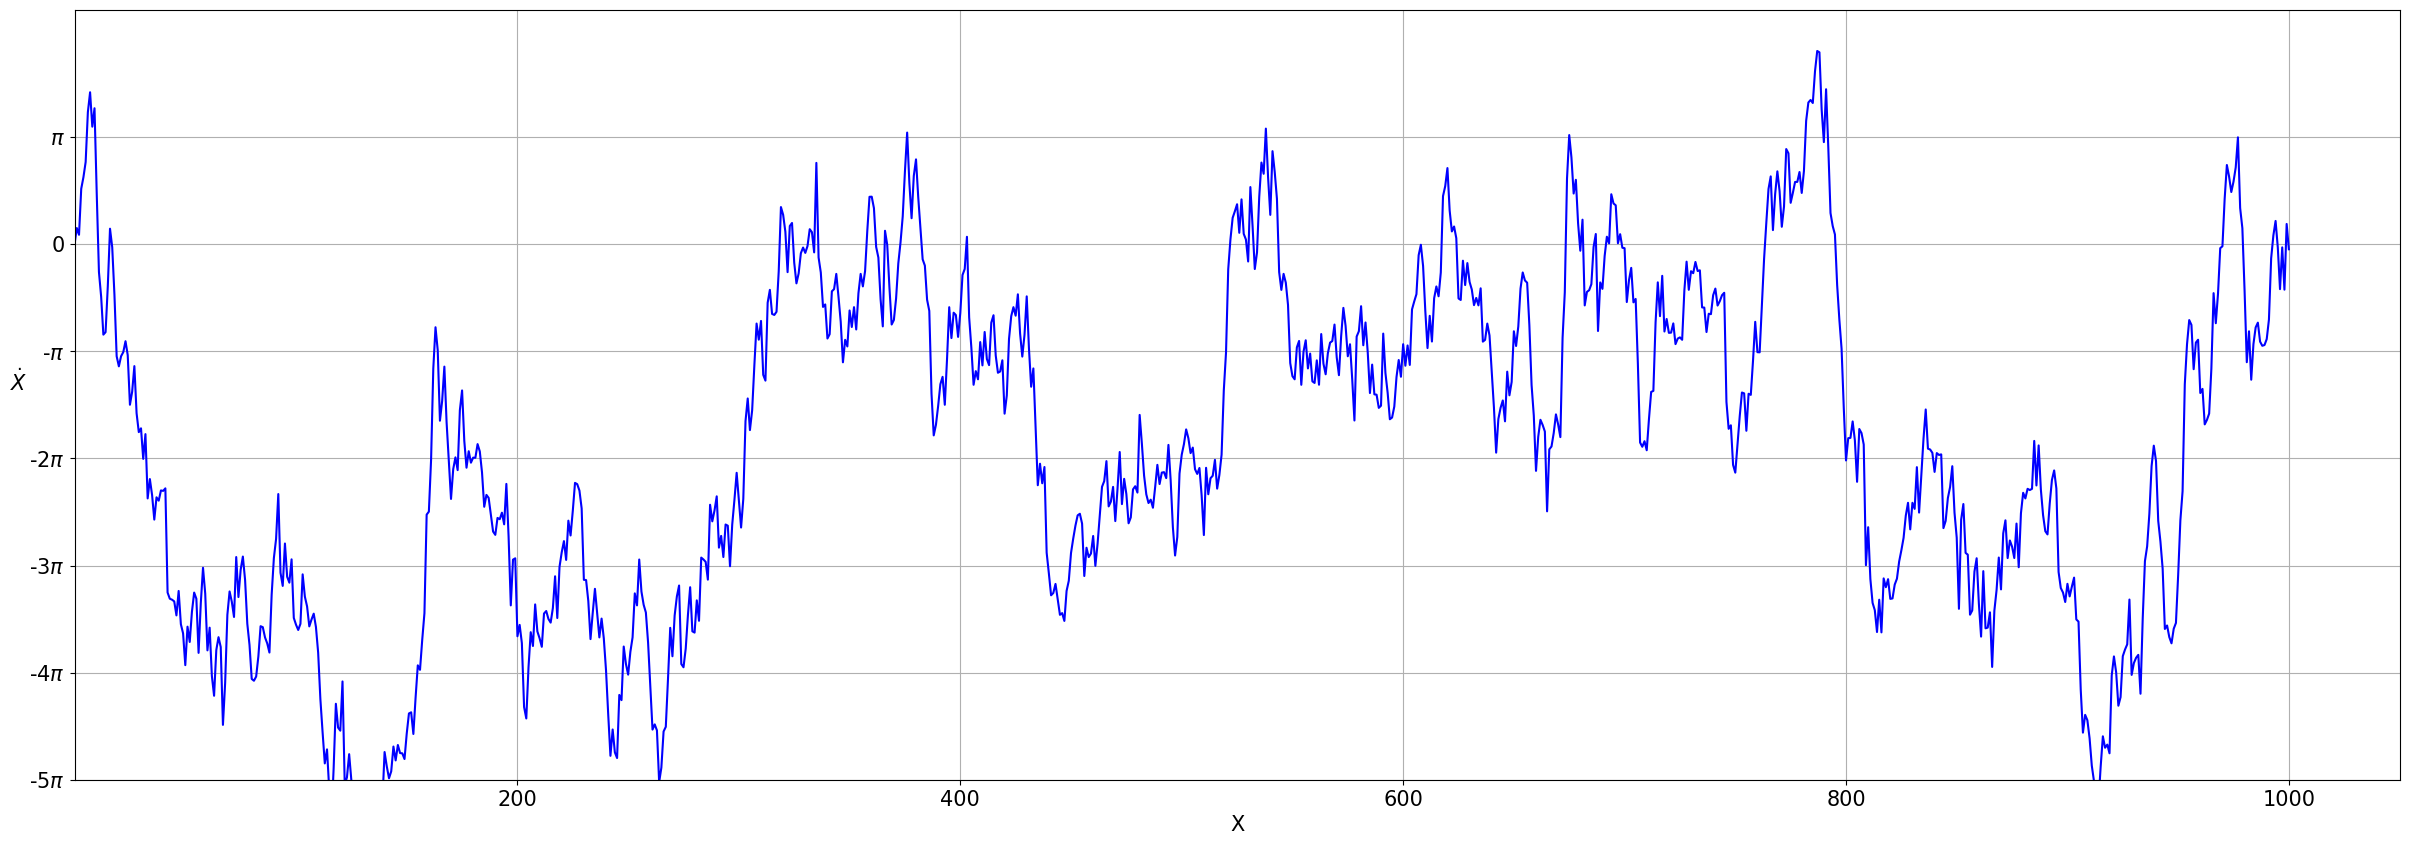

In [12]:
length = 1000  # 1_000
LENGTH = 100 # 100_000
figures = []

print('Plot #1')

#bp = Binary_Telegraph_Process(length, np.random.normal, 0, 1, RANDOM_SEED=[22], no_error=True)
#bp = Binary_Telegraph_Process(length, pink_noise(length), RANDOM_SEED=[22])
bp = Binary_Telegraph_Process(length, white_noise(length), RANDOM_SEED=[3])
#bp = Binary_Telegraph_Process(length, blue_noise(length), RANDOM_SEED=[2])
#bp = Binary_Telegraph_Process(length, brownian_noise(length), RANDOM_SEED=[2323])
#bp = Binary_Telegraph_Process(length, violet_noise(length), RANDOM_SEED=[2])

#dat, sii = bp.get_data() get_data_t4
dat, sii = bp.get_data(dt,D)
fig = plot_ax(dat, length)
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.ylabel(r'$\dot{X}$')
plt.xlabel('X')

plt.show()

#plt.savefig('plot_1.pdf')
#pdf = matplotlib.backends.backend_pdf.PdfPages("plot_1.pdf")

#pdf.savefig(fig)
#pdf.close()

In [13]:
bp.labels_new()

C:\Users\v-353\AppData\Local\Temp\ipykernel_24120\679657400.py:392: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data.iloc[i][1] != data.iloc[i-1][1]:


,data_pi,levels,MARKS
0,0.000000,0,0
1,0.150836,0,0
2,0.087624,0,0
3,0.517221,0,0
4,0.625786,0,0
...,...,...,...
996,-0.419554,0,0
997,-0.029668,0,0
998,-0.424617,0,0
999,0.188958,0,0


In [14]:
D_list = [10, 5, 2, 1, 0.75, 0.6, 0.5, 0.3, 0.1]

plot_list = []

for i in range(len(D_list)):
    deltas_vn = get_deltas_new(bp.data_to_pi(1,D_list[i]))
    plot_list.append(deltas_vn)


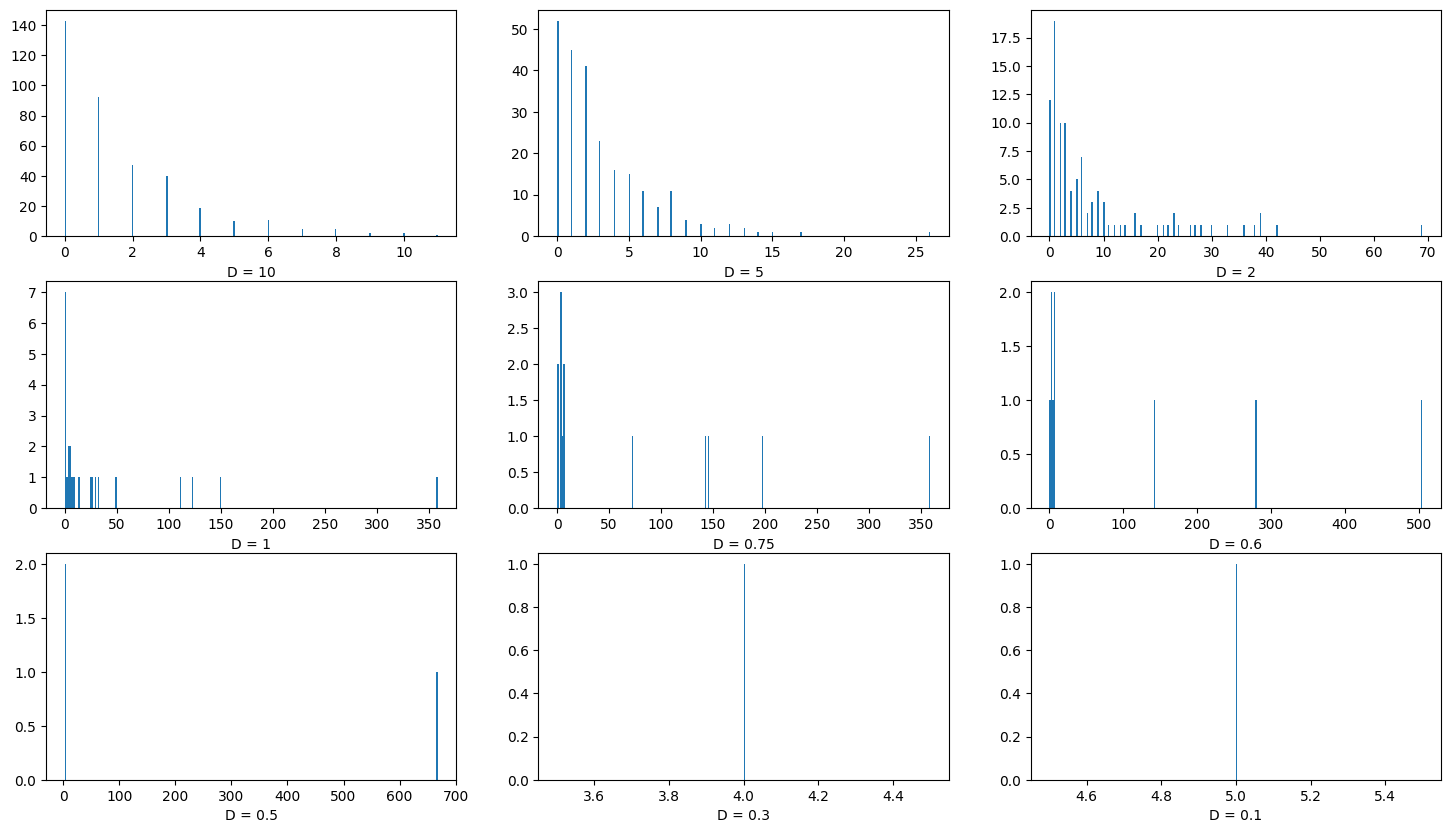

In [15]:
fig, ax = plt.subplots(3,3,figsize = (18,10))

for i in range(len(plot_list)):
  ax[i//3,i%3].hist(plot_list[i], bins=250)
  ax[i//3,i%3].set_xlabel(f'D = {D_list[i]}')


#fig.suptitle('White noise, distribution of time between transitions', fontsize=17)
#ax[0,2].hist(path_t4, density=False, bins=330)
#ax[0,2].set_xlabel('Path t4')

plt.show()


In [16]:
dt_list = [10, 2, 1, 0.01]
#D_list = [2, 1, 0.7, 0.5]
D_list = [1, 0.5, 0.1, 0.01]

plot_list = []

for i in range(len(dt_list)):
  for j in range(len(D_list)):
    deltas_vn = get_deltas_new(bp.data_to_pi(dt_list[i],D_list[j]))
    plot_list.append(deltas_vn)





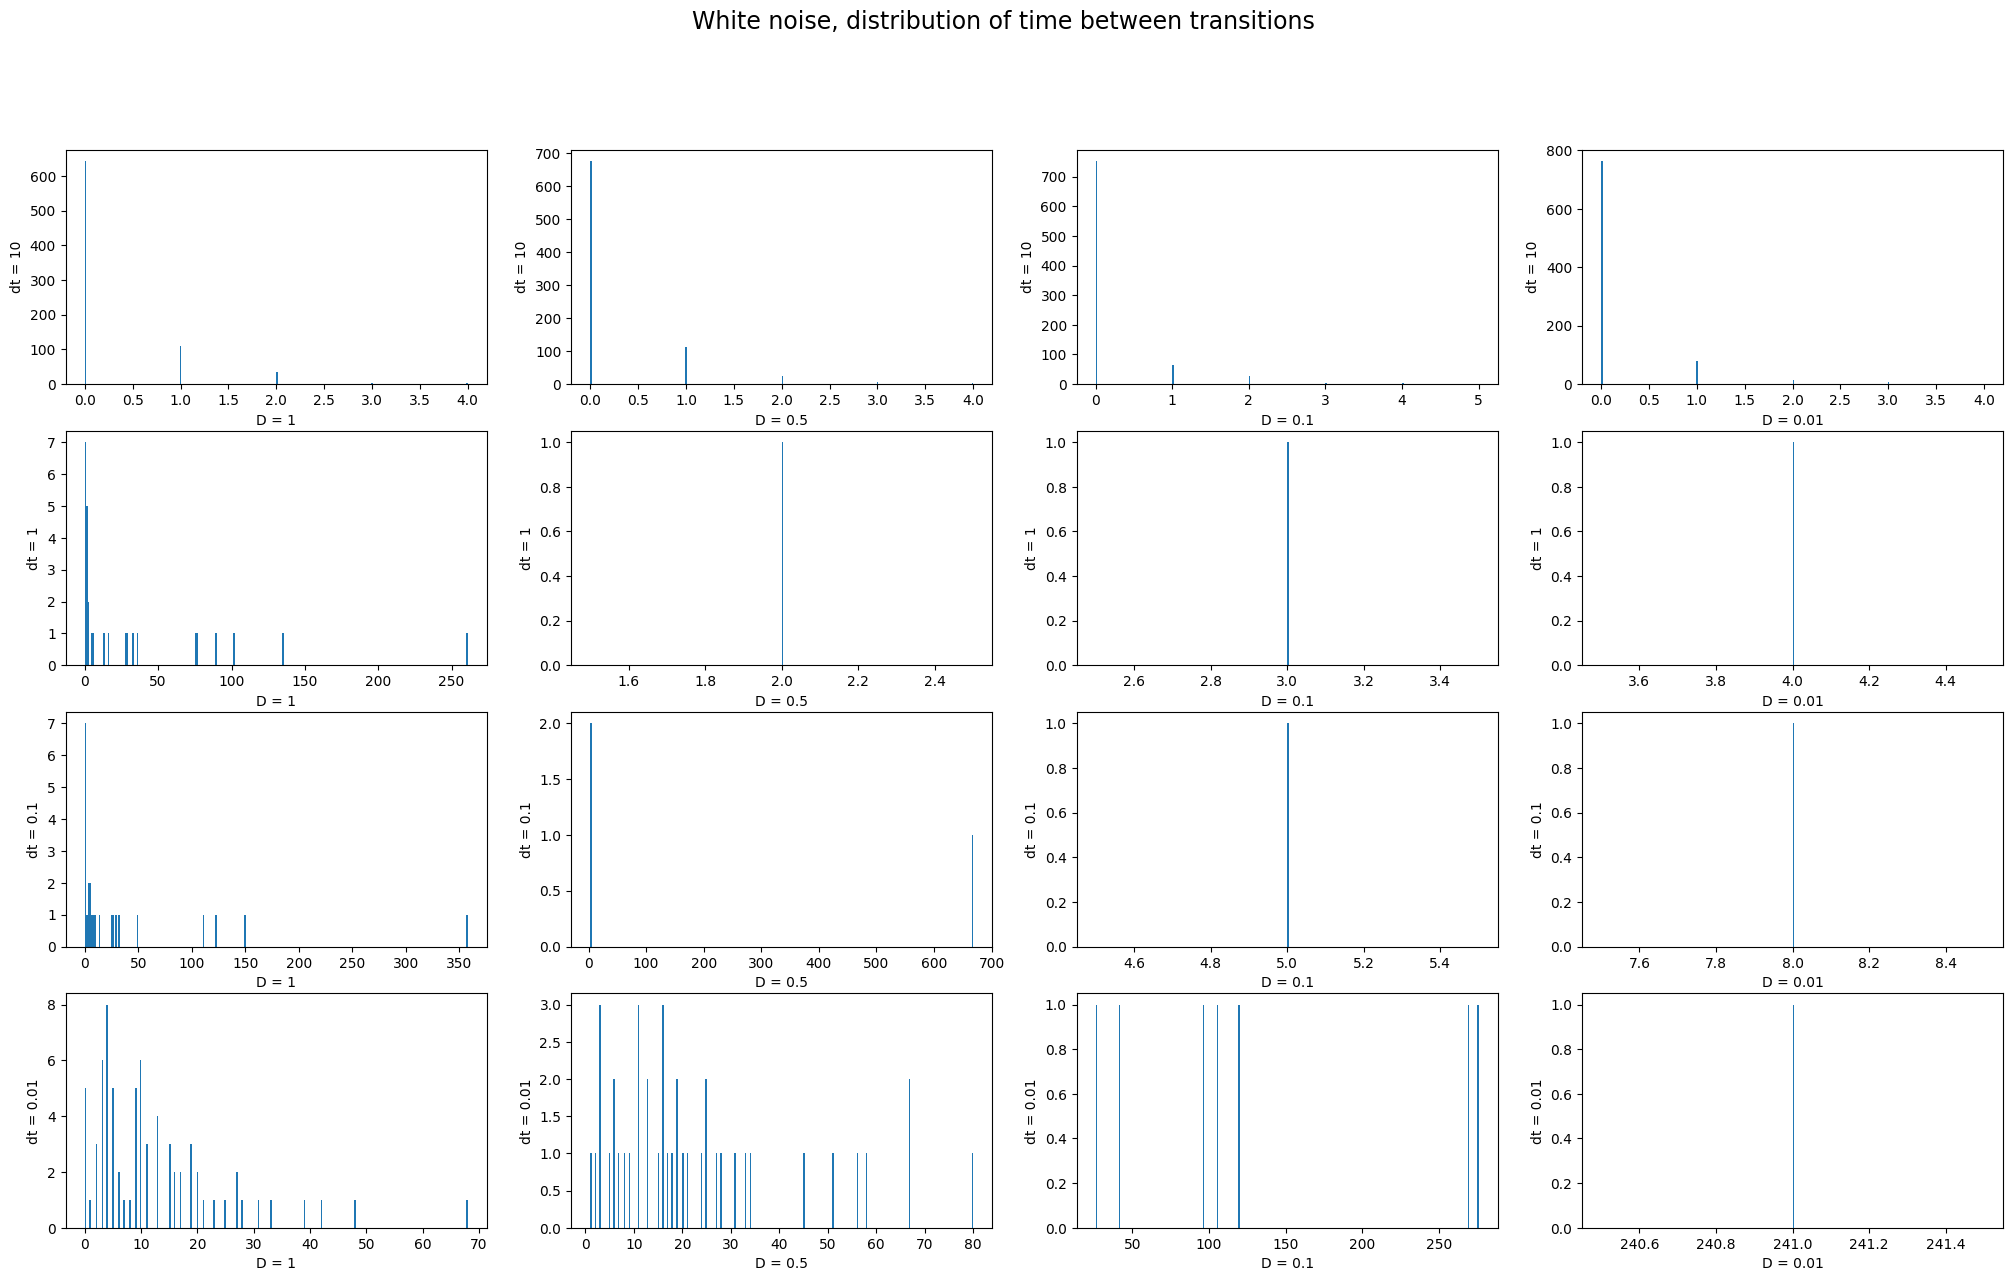

In [17]:
fig, ax = plt.subplots(4,4,figsize = (25,14))


ax[0,0].hist(plot_list[0], bins=250)
ax[0,0].set_xlabel('D = 1')
ax[0,0].set_ylabel('dt = 10')
ax[0,1].hist(plot_list[1], bins=250)
ax[0,1].set_xlabel('D = 0.5')
ax[0,1].set_ylabel('dt = 10')
ax[0,2].hist(plot_list[2], bins=250)
ax[0,2].set_xlabel('D = 0.1')
ax[0,2].set_ylabel('dt = 10')
ax[0,3].hist(plot_list[3], bins=250)
ax[0,3].set_xlabel('D = 0.01')
ax[0,3].set_ylabel('dt = 10')

ax[1,0].hist(plot_list[4], bins=250)
ax[1,0].set_xlabel('D = 1')
ax[1,0].set_ylabel('dt = 1')
ax[1,1].hist(plot_list[5], bins=250)
ax[1,1].set_xlabel('D = 0.5')
ax[1,1].set_ylabel('dt = 1')
ax[1,2].hist(plot_list[6], bins=250)
ax[1,2].set_xlabel('D = 0.1')
ax[1,2].set_ylabel('dt = 1')
ax[1,3].hist(plot_list[7], bins=250)
ax[1,3].set_xlabel('D = 0.01')
ax[1,3].set_ylabel('dt = 1')

ax[2,0].hist(plot_list[8], bins=250)
ax[2,0].set_xlabel('D = 1')
ax[2,0].set_ylabel('dt = 0.1')
ax[2,1].hist(plot_list[9], bins=250)
ax[2,1].set_xlabel('D = 0.5')
ax[2,1].set_ylabel('dt = 0.1')
ax[2,2].hist(plot_list[10], bins=250)
ax[2,2].set_xlabel('D = 0.1')
ax[2,2].set_ylabel('dt = 0.1')
ax[2,3].hist(plot_list[11], bins=250)
ax[2,3].set_xlabel('D = 0.01')
ax[2,3].set_ylabel('dt = 0.1')

ax[3,0].hist(plot_list[12], bins=250)
ax[3,0].set_xlabel('D = 1')
ax[3,0].set_ylabel('dt = 0.01')
ax[3,1].hist(plot_list[13], bins=250)
ax[3,1].set_xlabel('D = 0.5')
ax[3,1].set_ylabel('dt = 0.01')
ax[3,2].hist(plot_list[14], bins=250)
ax[3,2].set_xlabel('D = 0.1')
ax[3,2].set_ylabel('dt = 0.01')
ax[3,3].hist(plot_list[15], bins=250)
ax[3,3].set_xlabel('D = 0.01')
ax[3,3].set_ylabel('dt = 0.01')

fig.suptitle('White noise, distribution of time between transitions', fontsize=17)
#ax[0,2].hist(path_t4, density=False, bins=330)
#ax[0,2].set_xlabel('Path t4')

plt.show()

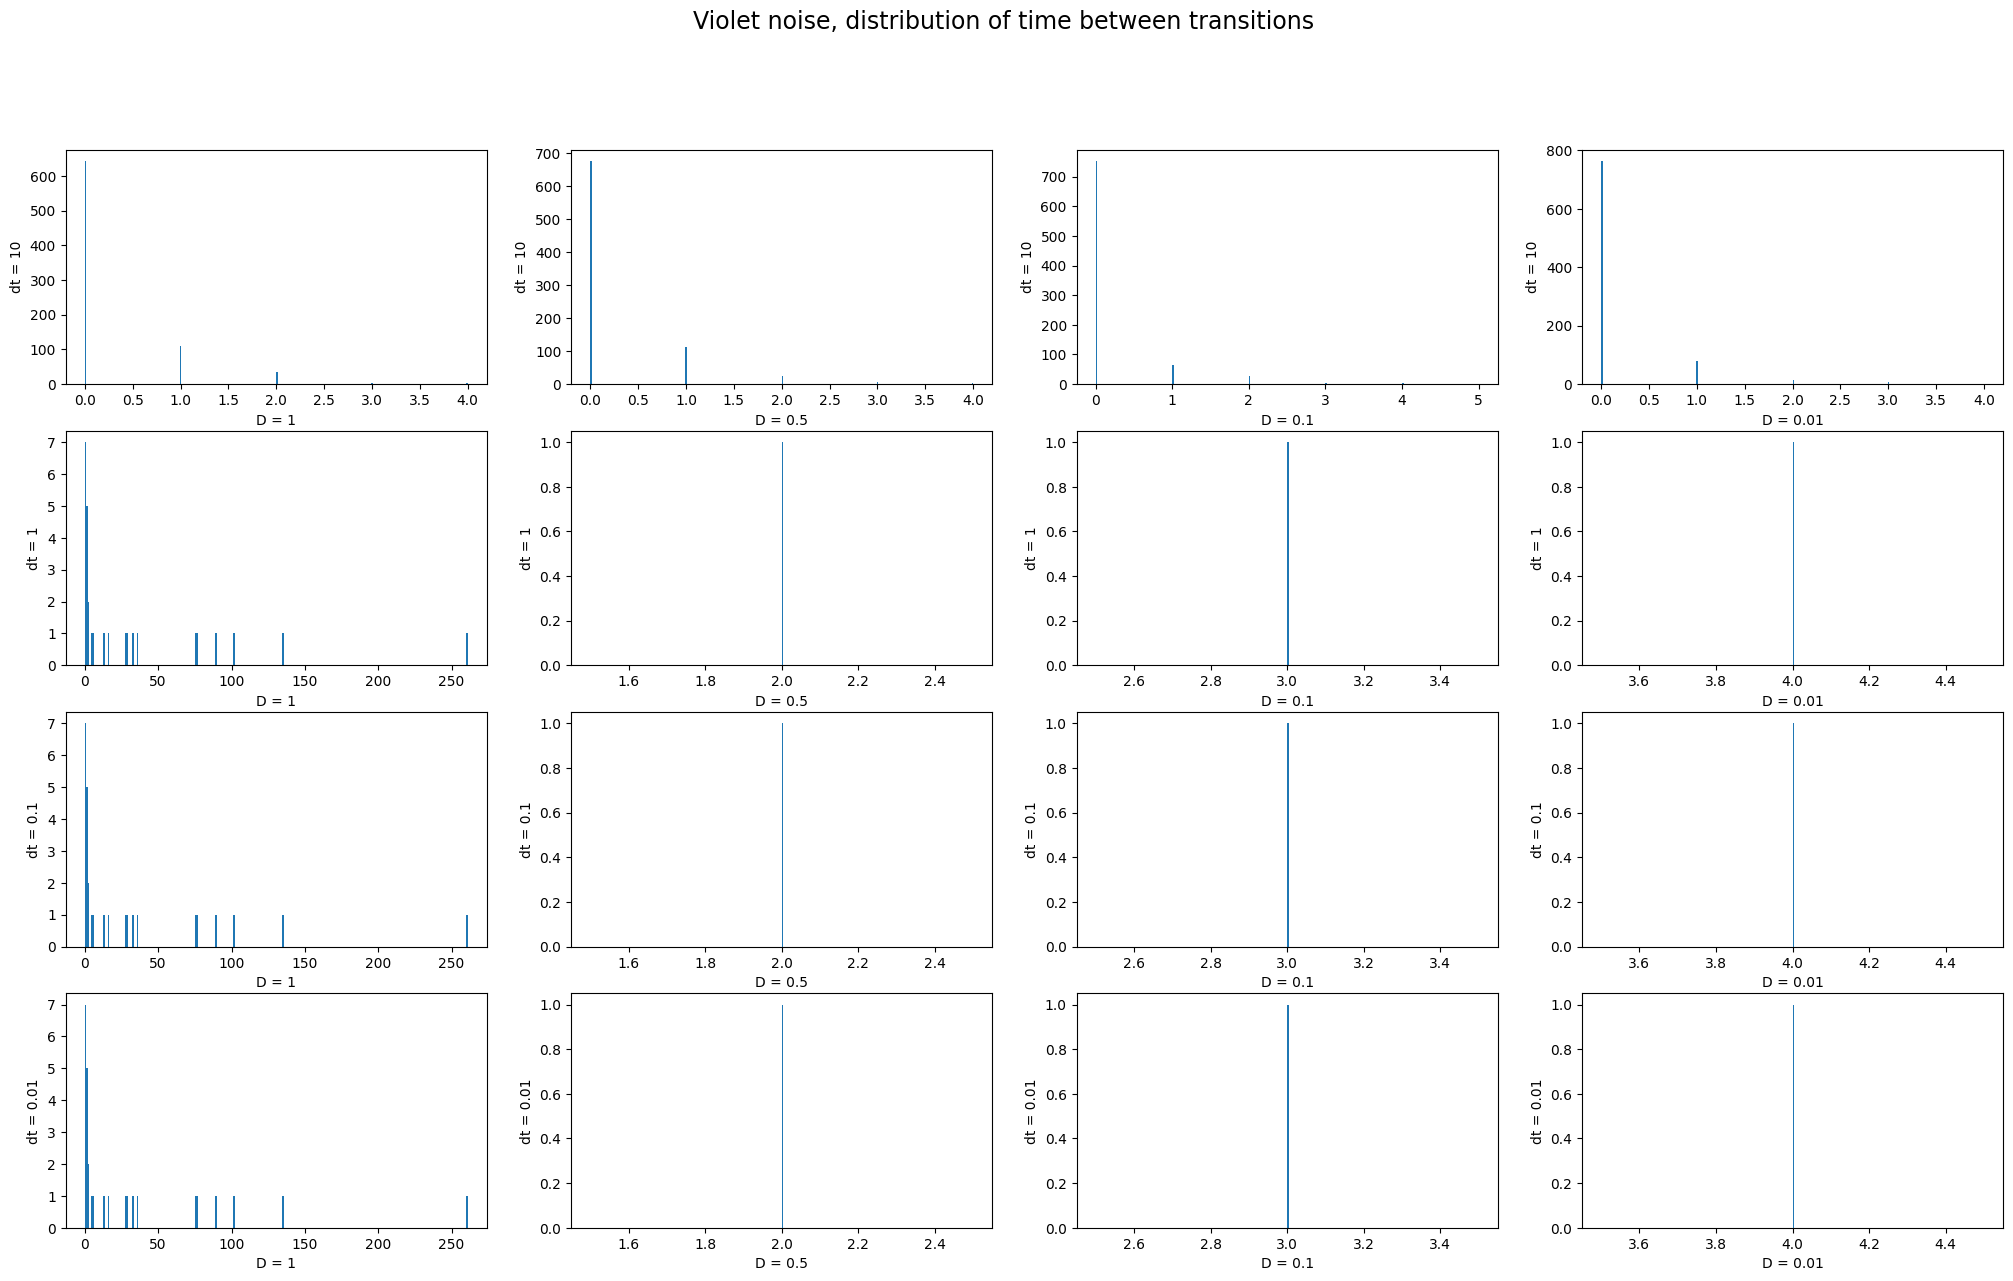

In [18]:
fig, ax = plt.subplots(4,4,figsize = (25,14))


ax[0,0].hist(plot_list[0], bins=250)
ax[0,0].set_xlabel('D = 1')
ax[0,0].set_ylabel('dt = 10')
ax[0,1].hist(plot_list[1], bins=250)
ax[0,1].set_xlabel('D = 0.5')
ax[0,1].set_ylabel('dt = 10')
ax[0,2].hist(plot_list[2], bins=250)
ax[0,2].set_xlabel('D = 0.1')
ax[0,2].set_ylabel('dt = 10')
ax[0,3].hist(plot_list[3], bins=250)
ax[0,3].set_xlabel('D = 0.01')
ax[0,3].set_ylabel('dt = 10')

ax[1,0].hist(plot_list[4], bins=250)
ax[1,0].set_xlabel('D = 1')
ax[1,0].set_ylabel('dt = 1')
ax[1,1].hist(plot_list[5], bins=250)
ax[1,1].set_xlabel('D = 0.5')
ax[1,1].set_ylabel('dt = 1')
ax[1,2].hist(plot_list[6], bins=250)
ax[1,2].set_xlabel('D = 0.1')
ax[1,2].set_ylabel('dt = 1')
ax[1,3].hist(plot_list[7], bins=250)
ax[1,3].set_xlabel('D = 0.01')
ax[1,3].set_ylabel('dt = 1')

ax[2,0].hist(plot_list[4], bins=250)
ax[2,0].set_xlabel('D = 1')
ax[2,0].set_ylabel('dt = 0.1')
ax[2,1].hist(plot_list[5], bins=250)
ax[2,1].set_xlabel('D = 0.5')
ax[2,1].set_ylabel('dt = 0.1')
ax[2,2].hist(plot_list[6], bins=250)
ax[2,2].set_xlabel('D = 0.1')
ax[2,2].set_ylabel('dt = 0.1')
ax[2,3].hist(plot_list[7], bins=250)
ax[2,3].set_xlabel('D = 0.01')
ax[2,3].set_ylabel('dt = 0.1')

ax[3,0].hist(plot_list[4], bins=250)
ax[3,0].set_xlabel('D = 1')
ax[3,0].set_ylabel('dt = 0.01')
ax[3,1].hist(plot_list[5], bins=250)
ax[3,1].set_xlabel('D = 0.5')
ax[3,1].set_ylabel('dt = 0.01')
ax[3,2].hist(plot_list[6], bins=250)
ax[3,2].set_xlabel('D = 0.1')
ax[3,2].set_ylabel('dt = 0.01')
ax[3,3].hist(plot_list[7], bins=250)
ax[3,3].set_xlabel('D = 0.01')
ax[3,3].set_ylabel('dt = 0.01')

fig.suptitle('Violet noise, distribution of time between transitions', fontsize=17)
#ax[0,2].hist(path_t4, density=False, bins=330)
#ax[0,2].set_xlabel('Path t4')

plt.show()

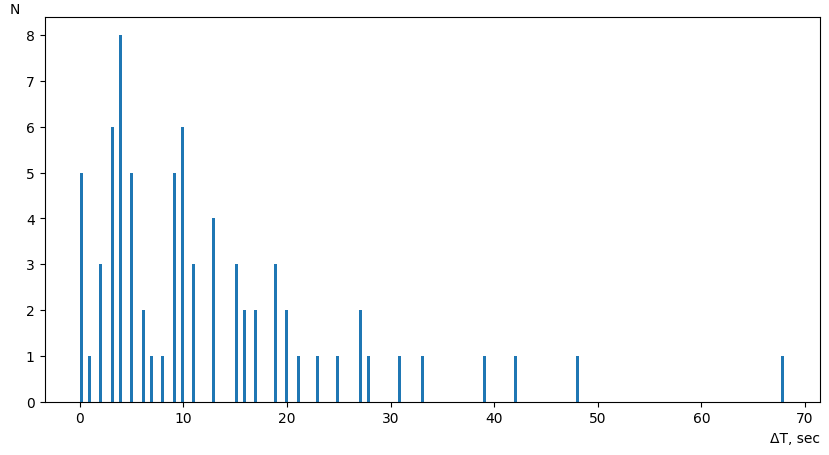

<Figure size 1500x1000 with 0 Axes>

In [19]:
#print('Violet Noise: Plot #4')

#bp = Binary_Telegraph_Process(LENGTH, violet_noise(LENGTH), RANDOM_SEED=[2])
deltas_vn = get_deltas_new(bp.data_to_pi(dt,D))

df = pd.DataFrame(deltas_vn)
#print(df)
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(deltas_vn, bins=250)
#ax.hist(deltas_vn,density = False)
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
#plt.xlim([0, 50])
#plt.axis('scaled')
plt.figure(figsize = (15,10))

# plt.savefig('violet_noise_4.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("violer_noise_4.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()

NameError: name 'path_t0' is not defined

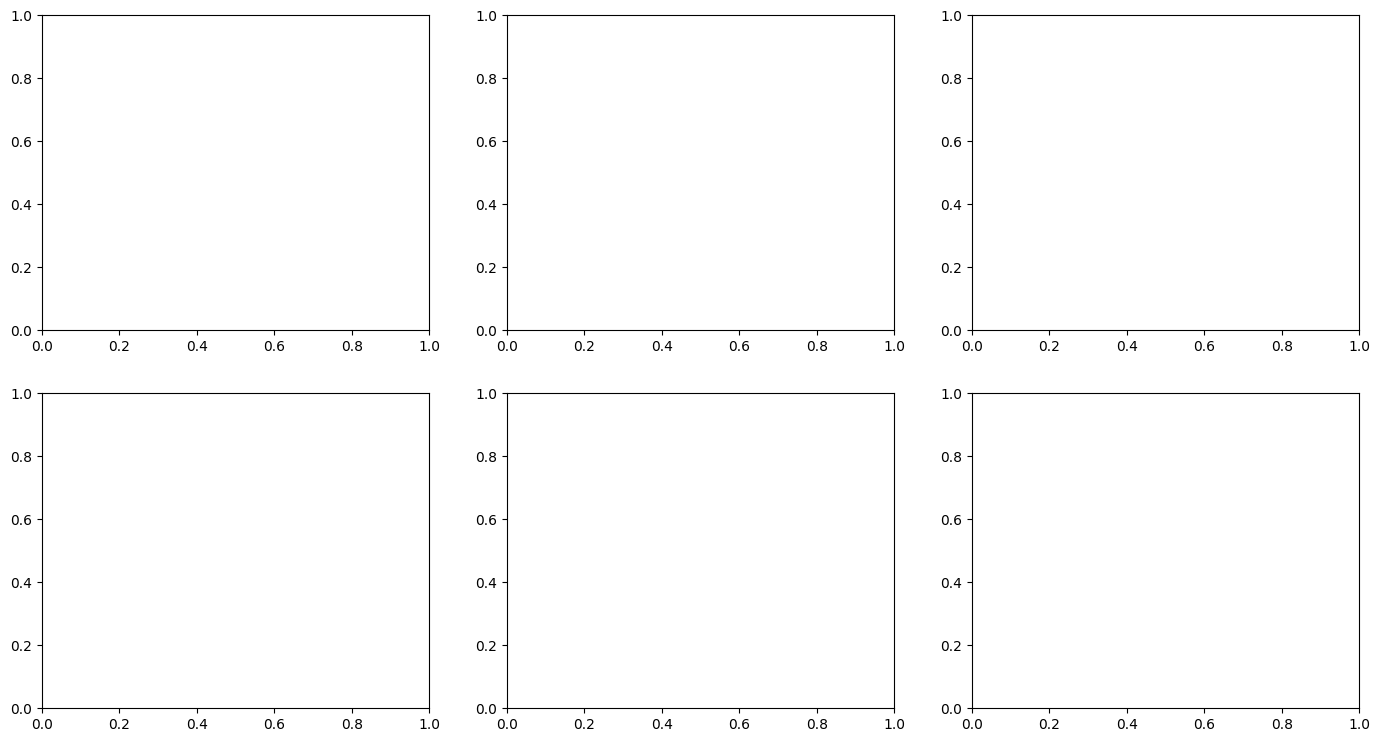

In [20]:
fig, ax = plt.subplots(2,3,figsize = (17,9))
ax[0,0].hist(path_t0, density=False, bins=1030)
ax[0,0].set_xlabel('Path t0')
ax[0,1].hist(path_t1, density=False, bins=1030)
ax[0,1].set_xlabel('Path t1')
ax[1,0].hist(path_t2, density=False, bins=1030)
ax[1,0].set_xlabel('Path t2')
ax[1,1].hist(path_t3, density=False, bins=330)
ax[1,1].set_xlabel('Path t3')
ax[0,2].hist(path_t4, density=False, bins=330)
ax[0,2].set_xlabel('Path t4')
plt.show()

In [21]:
df

,0
0,5
1,4
2,7
3,11
4,10
...,...
69,9
70,0
71,16
72,9


In [22]:
pd.set_option('display.max_rows', None)
bp.data_to_pi(dt,D).head(500)

,data_pi,levels
0,0.000000,0
1,0.150836,0
2,0.087624,0
3,0.517221,0
4,0.625786,0
5,0.767485,0
6,1.233053,1
7,1.418461,1
8,1.097235,1
9,1.269253,1


Plot #1


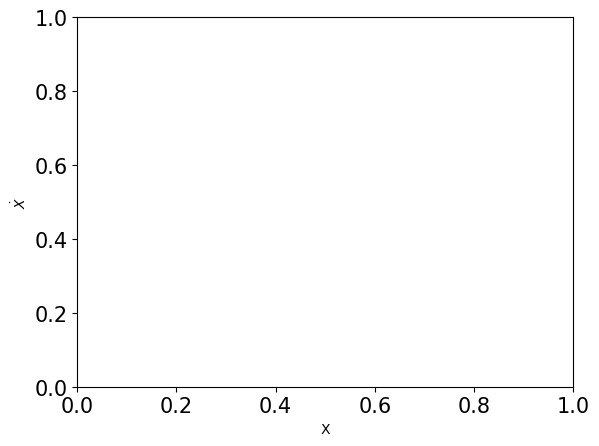

In [ ]:
length = 100000  # 1_000
LENGTH = 100 # 100_000
figures = []

print('Plot #1')

#bp = Binary_Telegraph_Process(length, np.random.normal, 0, 1, RANDOM_SEED=[22], no_error=True)
bp = Binary_Telegraph_Process(length, pink_noise(length), RANDOM_SEED=[22])
#bp = Binary_Telegraph_Process(length, white_noise(length), RANDOM_SEED=[3])
#bp = Binary_Telegraph_Process(length, blue_noise(length), RANDOM_SEED=[2])
#bp = Binary_Telegraph_Process(length, brownian_noise(length), RANDOM_SEED=[2323])
#bp = Binary_Telegraph_Process(length, violet_noise(length), RANDOM_SEED=[2])

#dat, sii = bp.get_data() get_data_t4
dat, sii = bp.get_data_t4(1)
#fig = plot_ax(dat, length)
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.ylabel(r'$\dot{X}$')
plt.xlabel('X')

plt.show()

#plt.savefig('plot_1.pdf')
#pdf = matplotlib.backends.backend_pdf.PdfPages("plot_1.pdf")

#pdf.savefig( fig )
#pdf.close()

In [ ]:
deltas_vn, indexes_vn = get_deltas_new(bp.data_to_pi_wt4())


deltas_vn

In [ ]:
deltas = pd.DataFrame()
deltas['deltas'] = deltas_vn

deltas['deltas'].unique()



array([  4,  42,   1,   6,   0,   2,  82,   7,  21,  45,   3,  54,  27,
        60,   5,  14,  81,  10,  58,  15,   8,  67,  86,  16, 126,  85,
        17,  34,   9,  12,  11,  28,  26,  22,  47,  97,  62,  56,  73,
        23,  50,  31,  13, 144,  19,  48,  30, 239,  25, 177,  24, 120,
        87,  40,  49,  63, 146,  53,  37,  20,  18,  44,  33,  35,  51,
        39,  38,  72, 131,  32,  96,  36,  89,  57,  29,  43,  77,  46,
       107,  71,  41,  78,  55,  52, 125,  75,  70,  93,  61, 140, 161,
        66,  90,  80, 112,  59,  94, 101,  79,  69,  68,  88,  65,  99,
        64, 143, 117, 119, 100, 129, 102, 160,  92,  74,  76, 106, 134,
       105, 127, 155, 128,  84, 124, 133, 104,  95, 184, 108, 181, 122,
       121,  91, 110, 191, 167, 113, 115,  83, 109, 116, 203,  98])

In [ ]:
df = deltas['deltas'].value_counts(sort = True).reset_index()
df.columns = ['deltas', 'count']
df

In [ ]:
pd.set_option('display.max_rows', 500)

#pi_data = bp.data_to_pi()
pi_data = bp.data_to_pi_wt4()
pi_data

,data_pi,true_pi,levels
0,0.000000,0.000000,0
1,-0.173019,-0.173019,0
2,-0.328064,-0.328064,0
3,-0.557598,-0.557598,0
4,-0.644111,-0.644111,0
...,...,...,...
99996,1124.895139,1124.895139,1125
99997,1125.409643,1125.409643,1125
99998,1124.572689,1124.572689,1125
99999,1125.444030,1125.444030,1125


In [ ]:
t_c = bp.transition_catch_wt4()
t_c['data_pi'] = pi_data['data_pi']
t_c['levels'] = pi_data['levels']
t_c['sinx'] = sii['sinx']
t_c['errors'] = sii['errors']


In [ ]:
t_c.tail(500)

In [ ]:
t_c.iloc[[474, 475,476]]

In [ ]:
t_c.loc[t_c['trans_type'] == 4]

In [ ]:
t_c.loc[t_c['trans_type'] == 4]

In [ ]:
t_c.head(100)

In [ ]:
path_t0 = []
path_t1 = []
path_t2 = []
path_t3 = []
path_t4 = []

for i in range(len(t_c)):
  if t_c['trans_type'][i] == 0:
    path_t0.append(float(t_c['path'][i]))
  elif t_c['trans_type'][i] == 1:
    path_t1.append(float(t_c['path'][i]))
  elif t_c['trans_type'][i] == 2:
    path_t2.append(float(t_c['path'][i]))
  elif t_c['trans_type'][i] == 3:
    path_t3.append(float(t_c['path'][i]))
  elif t_c['trans_type'][i] == 4:
    path_t4.append(float(t_c['path'][i]))


Text(0.5, 0, 'Type of trans')

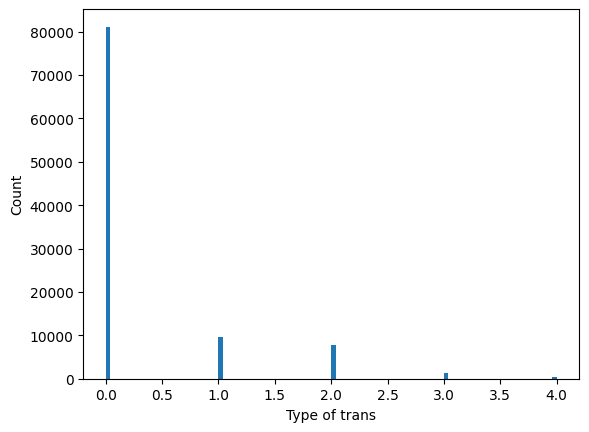

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

plt.hist(t_c['trans_type'], density=False, bins=100)  # density=False would make counts
plt.ylabel('Count')
plt.xlabel('Type of trans')

Text(0.5, 0, 'Path of t0')

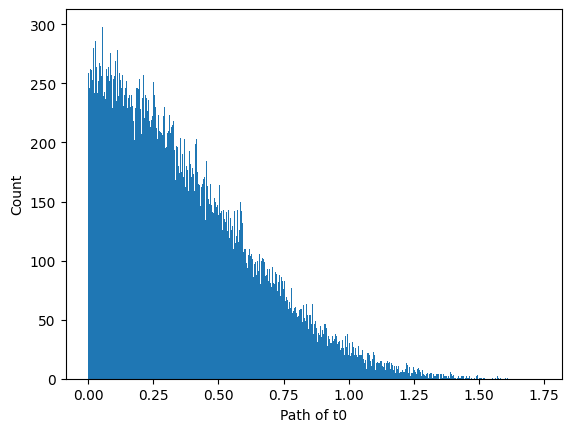

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

plt.hist(path_t0, density=False, bins=1030)  # density=False would make counts
plt.ylabel('Count')
plt.xlabel('Path of t0')



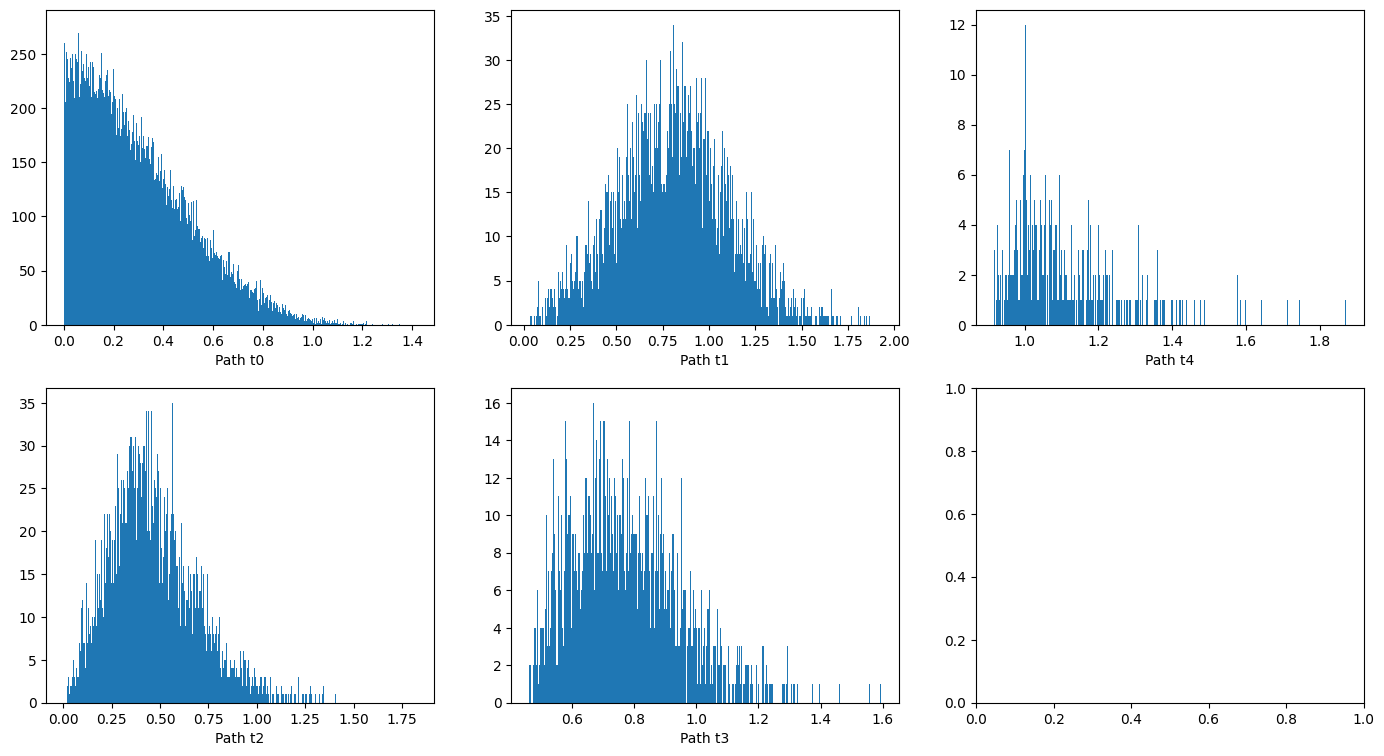

In [ ]:
fig, ax = plt.subplots(2,3,figsize = (17,9))
ax[0,0].hist(path_t0, density=False, bins=1030)
ax[0,0].set_xlabel('Path t0')
ax[0,1].hist(path_t1, density=False, bins=1030)
ax[0,1].set_xlabel('Path t1')
ax[1,0].hist(path_t2, density=False, bins=1030)
ax[1,0].set_xlabel('Path t2')
ax[1,1].hist(path_t3, density=False, bins=330)
ax[1,1].set_xlabel('Path t3')
ax[0,2].hist(path_t4, density=False, bins=330)
ax[0,2].set_xlabel('Path t4')
plt.show()

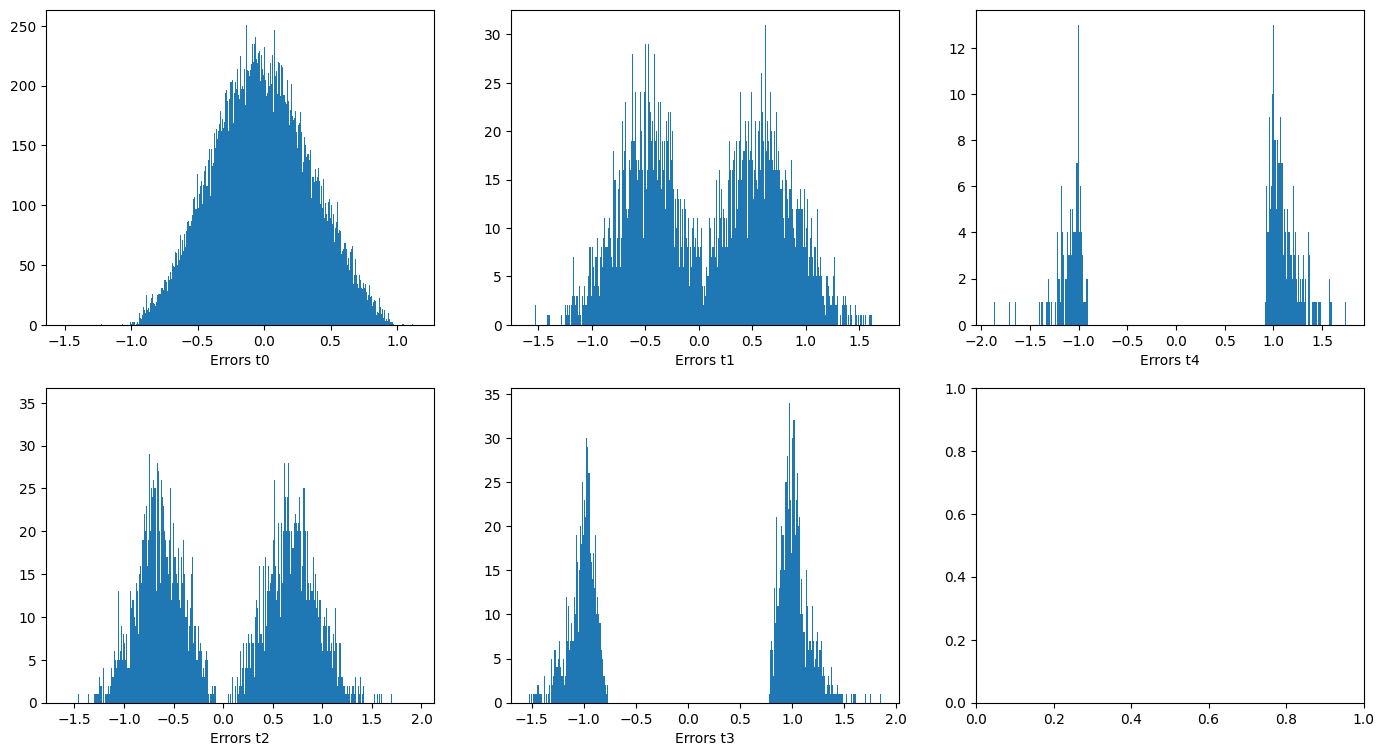

In [ ]:
fig, ax = plt.subplots(2,3,figsize = (17,9))
ax[0,0].hist(t_c['errors'].where(t_c['trans_type'] == 0)/math.pi, density=False, bins=1030)
ax[0,0].set_xlabel('Errors t0')
ax[0,1].hist(t_c['errors'].where(t_c['trans_type'] == 1)/math.pi, density=False, bins=1030)
ax[0,1].set_xlabel('Errors t1')
ax[1,0].hist(t_c['errors'].where(t_c['trans_type'] == 2)/math.pi, density=False, bins=1030)
ax[1,0].set_xlabel('Errors t2')
ax[1,1].hist(t_c['errors'].where(t_c['trans_type'] == 3)/math.pi, density=False, bins=330)
ax[1,1].set_xlabel('Errors t3')
ax[0,2].hist(t_c['errors'].where(t_c['trans_type'] == 4)/math.pi, density=False, bins=330)
ax[0,2].set_xlabel('Errors t4')
plt.show()

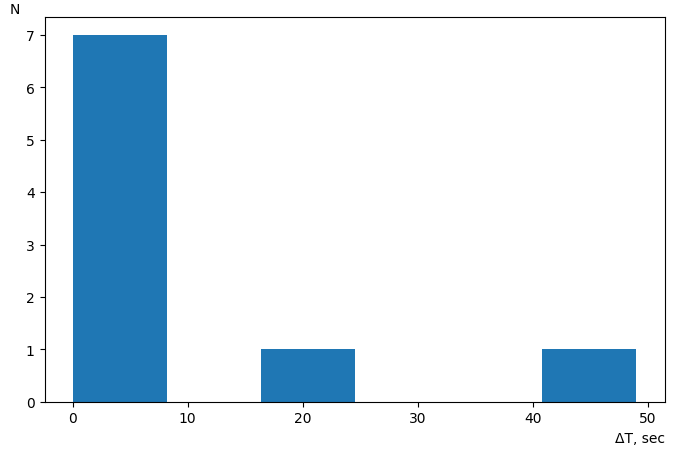

<Figure size 1500x1000 with 0 Axes>

In [ ]:
#print('Pink Noise: Plot #4')

#bp = Binary_Telegraph_Process(length, pink_noise(length), RANDOM_SEED=[133])
clusters = bp.clusters()
deltas = get_deltas(bp.clusters())
df = pd.DataFrame(deltas)

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(deltas,len(df.value_counts()))
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
plt.figure(figsize = (15,10))

# plt.savefig('pink_noise_4.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("pink_noise_4.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()

Plot #2


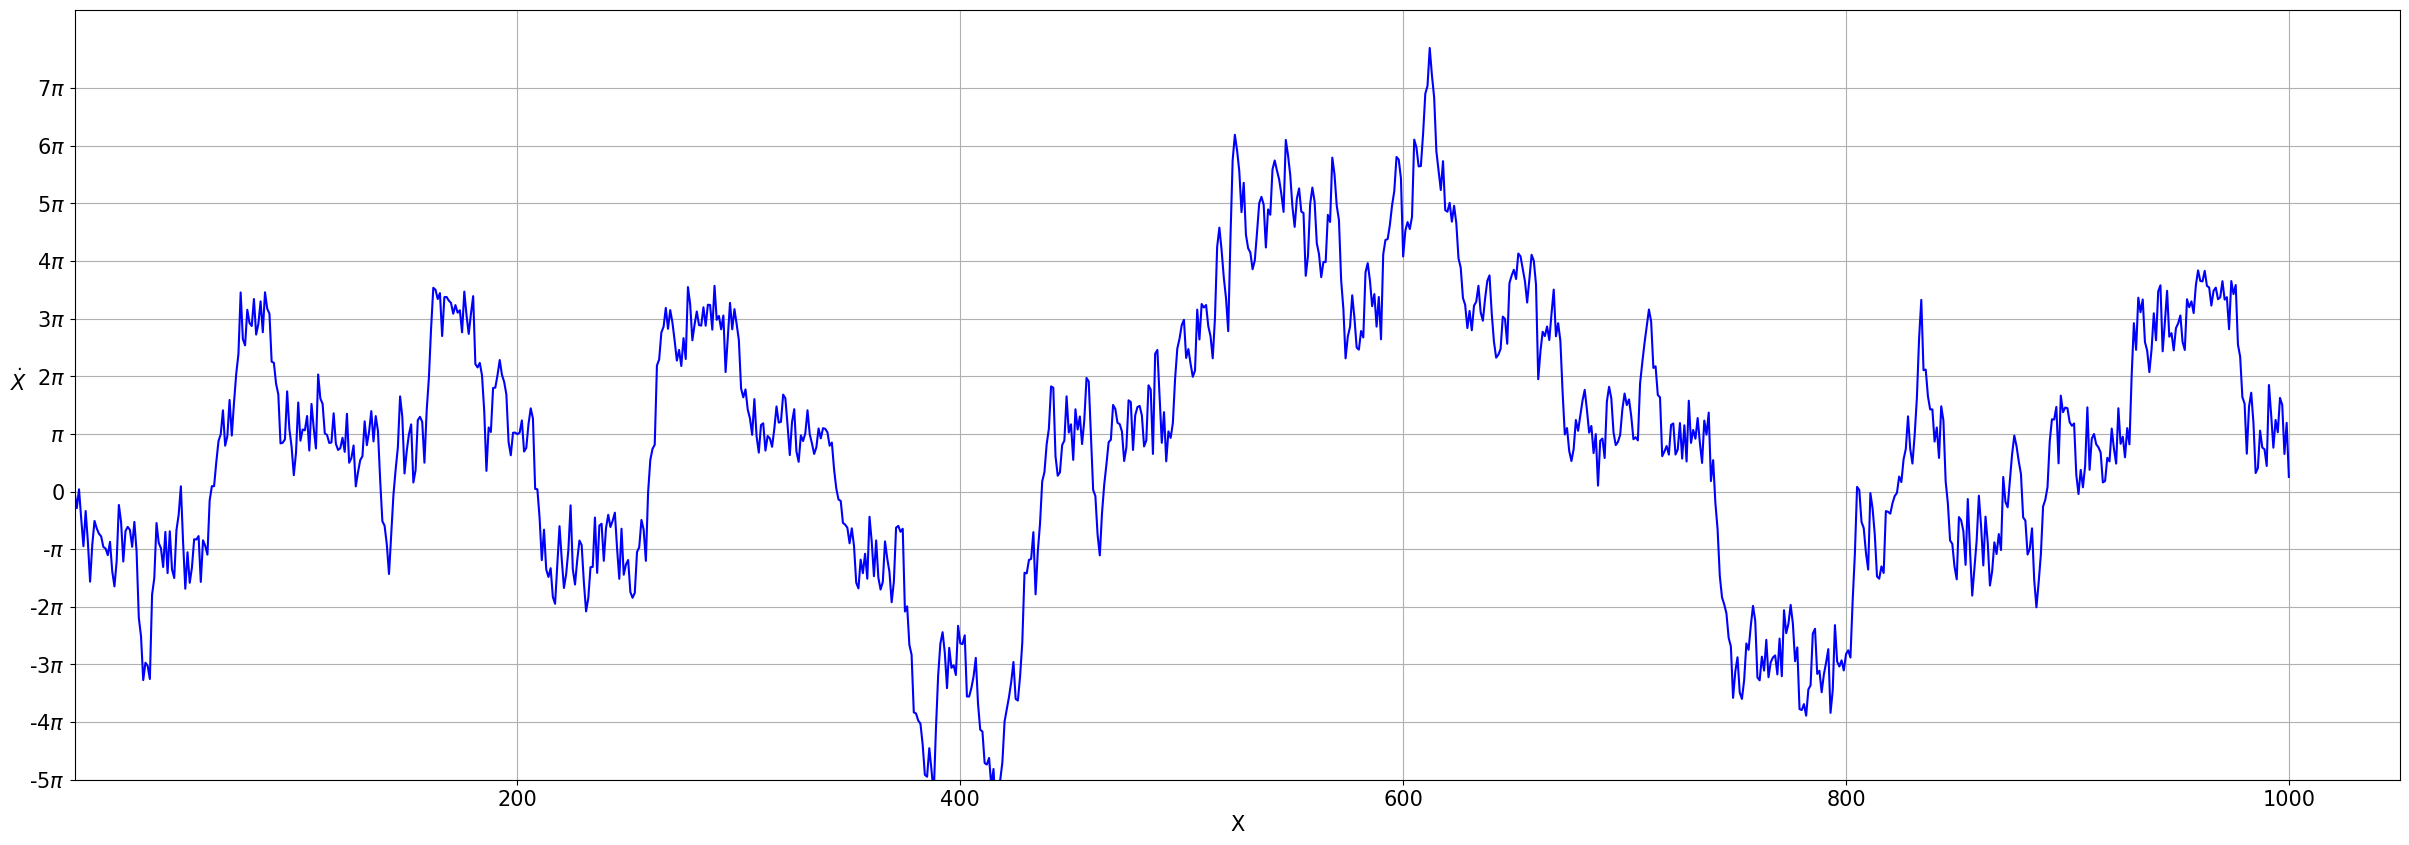

In [ ]:
print('Plot #2')

bp = Binary_Telegraph_Process(length, np.random.normal, 0, 1, RANDOM_SEED=[22])

fig = plot_ax(bp.get_data(), length)

#plt.legend(loc = 'upper right', fontsize = 18)
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.xlabel('X')
plt.ylabel(r'$\dot{X}$')

plt.savefig('plot_2.pdf')
pdf = matplotlib.backends.backend_pdf.PdfPages("plot_2.pdf")

pdf.savefig( fig )
pdf.close()
plt.show()

Pink Noise: Plot #3


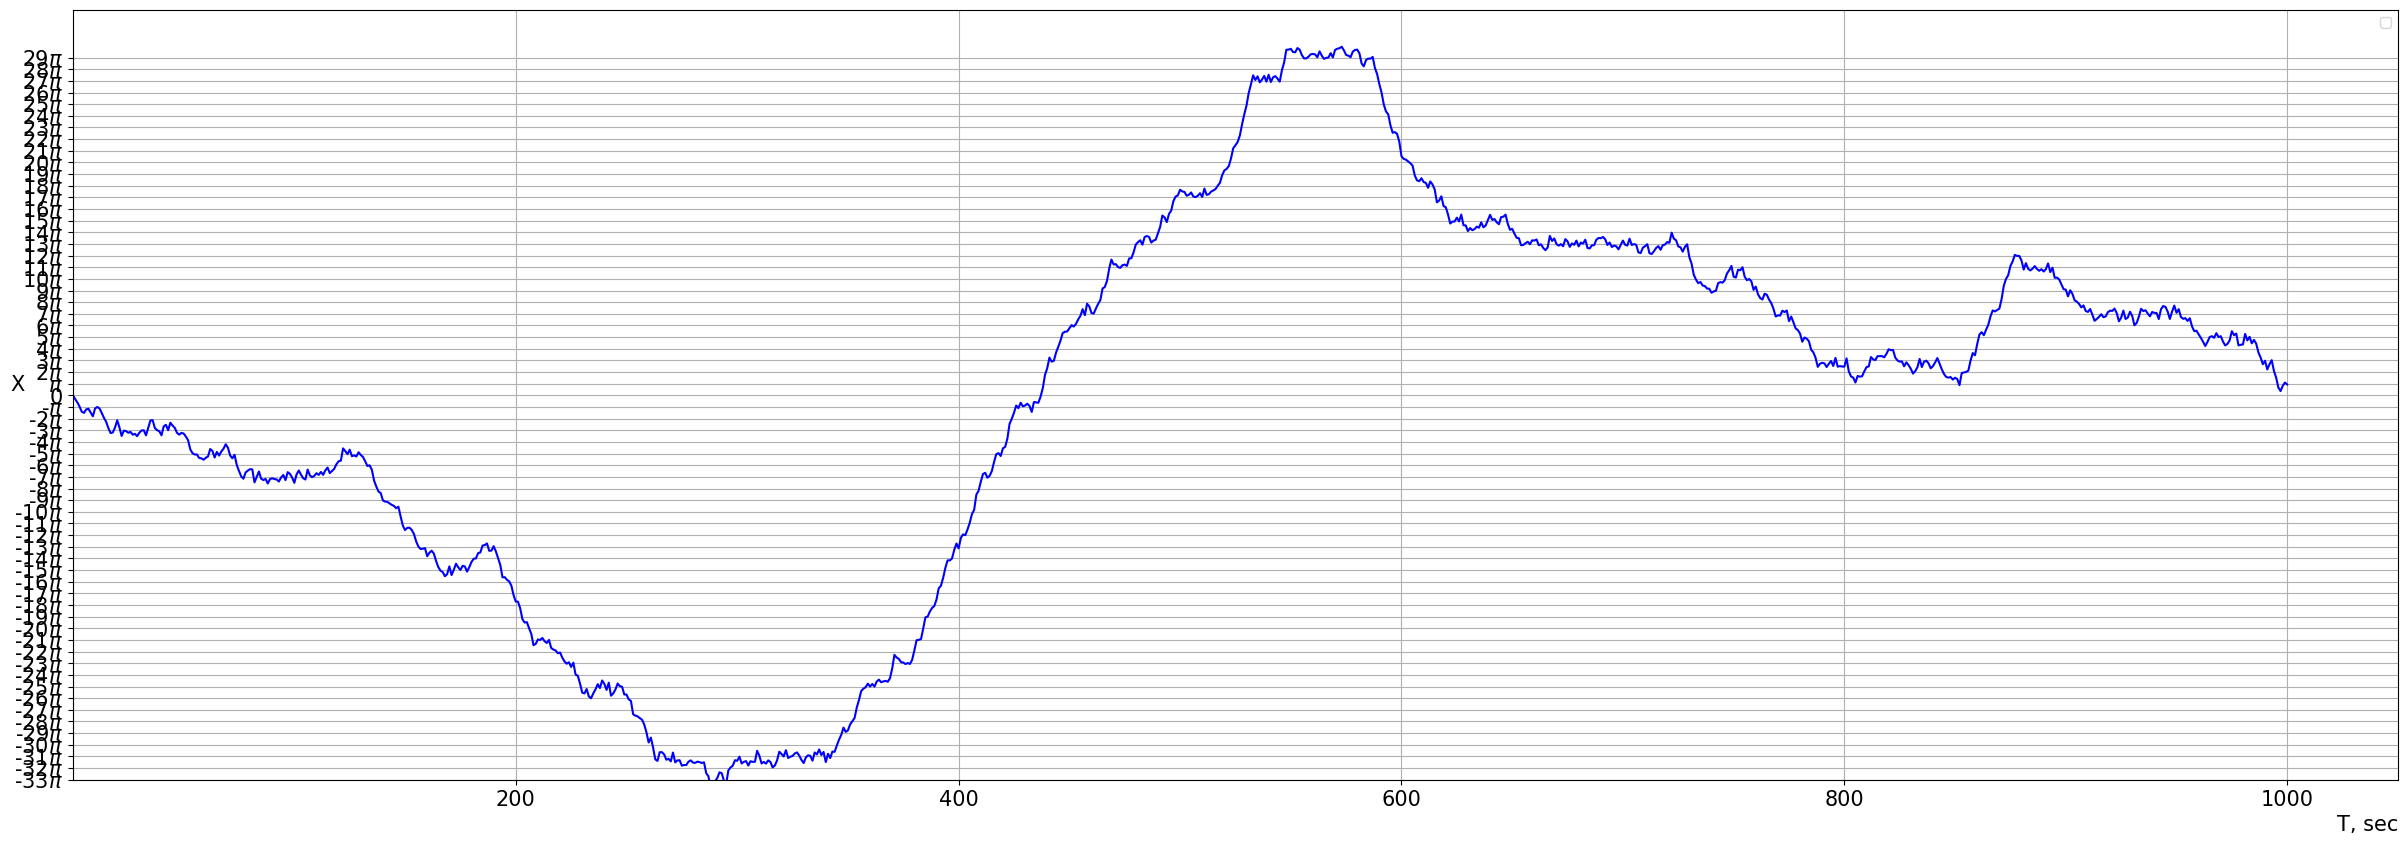

In [ ]:
print('Pink Noise: Plot #3')

bp = Binary_Telegraph_Process(length, pink_noise(length), RANDOM_SEED=[222])

fig = plot_ax(bp.get_data(), length)
plt.xlabel('T, sec', loc = 'right')
plt.ylabel('X')

plt.legend()
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.savefig('pink_noise_3.pdf')
pdf = matplotlib.backends.backend_pdf.PdfPages("pink_noise_3.pdf")

pdf.savefig( fig )
pdf.close()

plt.show()

Brown Noise: Plot #3


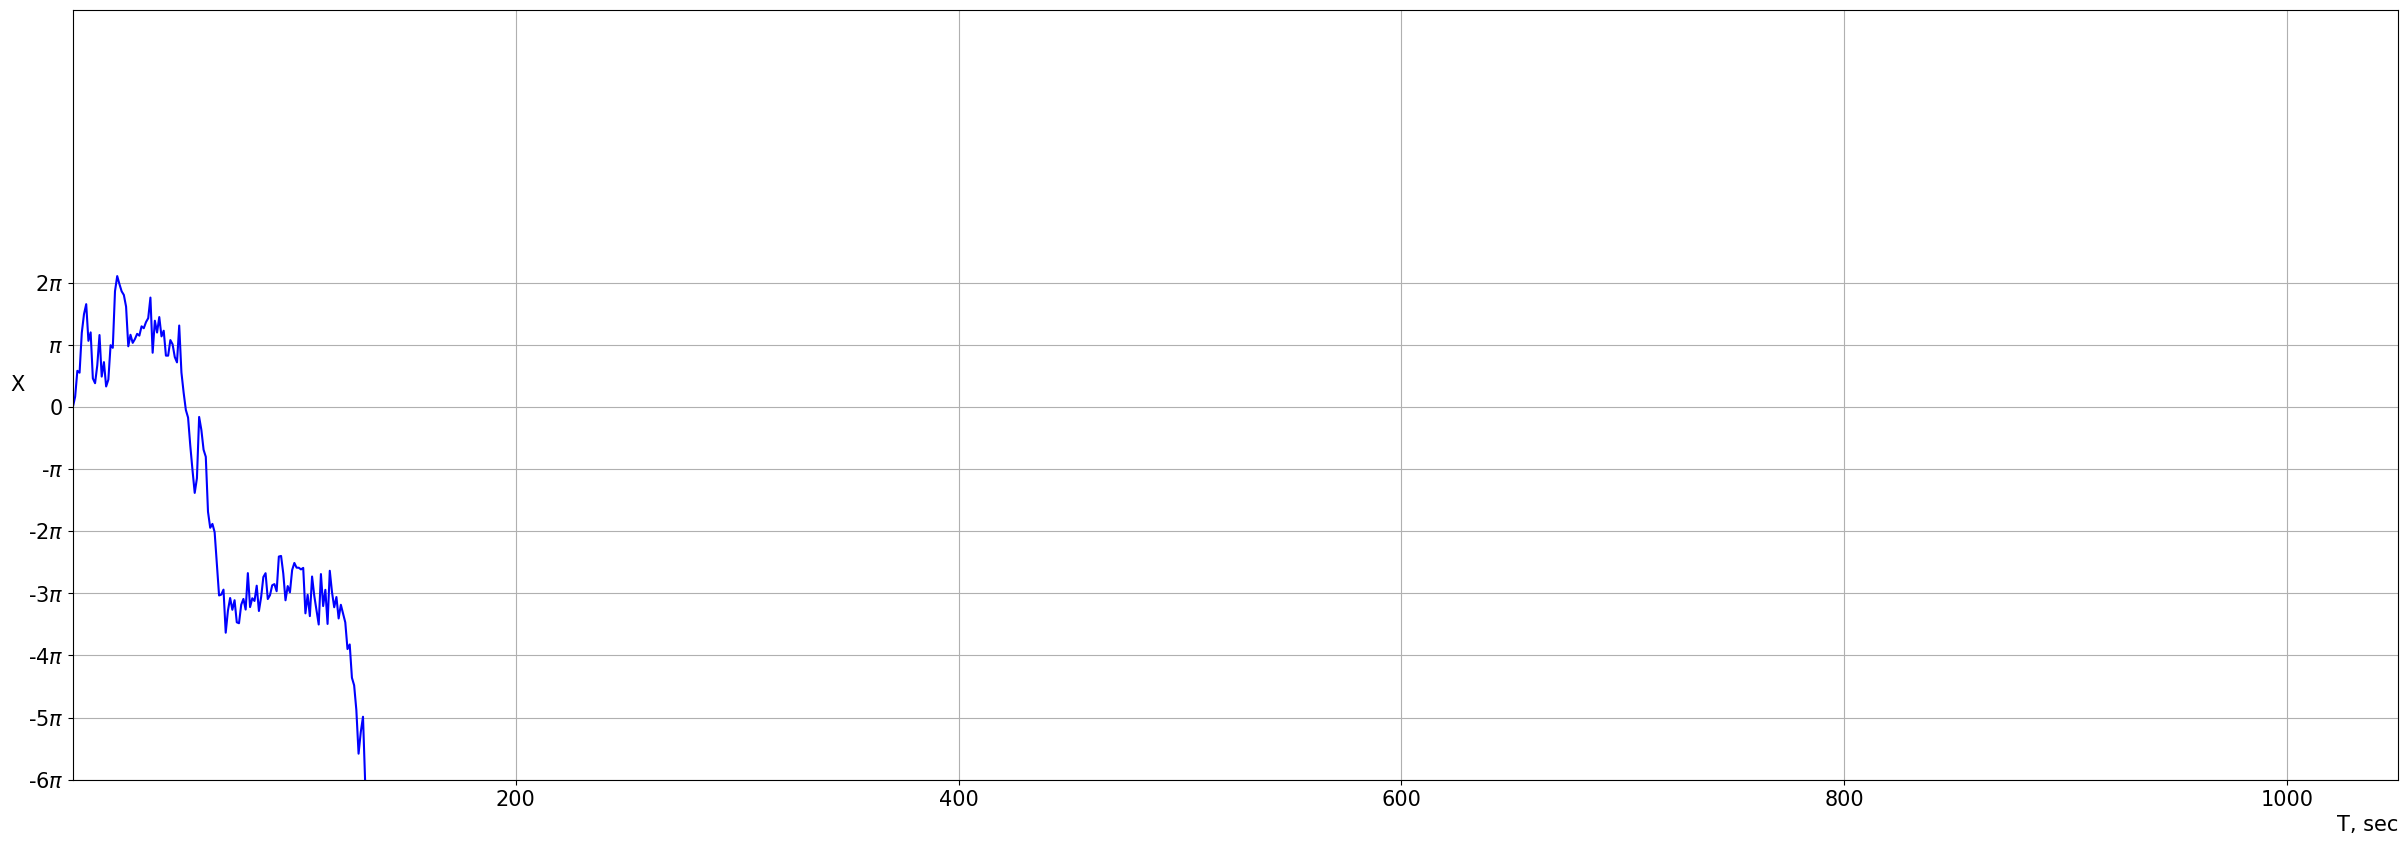

In [ ]:
print('Brown Noise: Plot #3')

bp = Binary_Telegraph_Process(length, brownian_noise(length), RANDOM_SEED=[2])

fig = plot_ax(bp.get_data(), length)

plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)

plt.xlabel('T, sec', loc = 'right')
plt.ylabel('X')
plt.ylim(-6*np.pi)

# plt.savefig('brownian_noise_3.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("brownian_noise_3.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()

Pink Noise: Plot #3


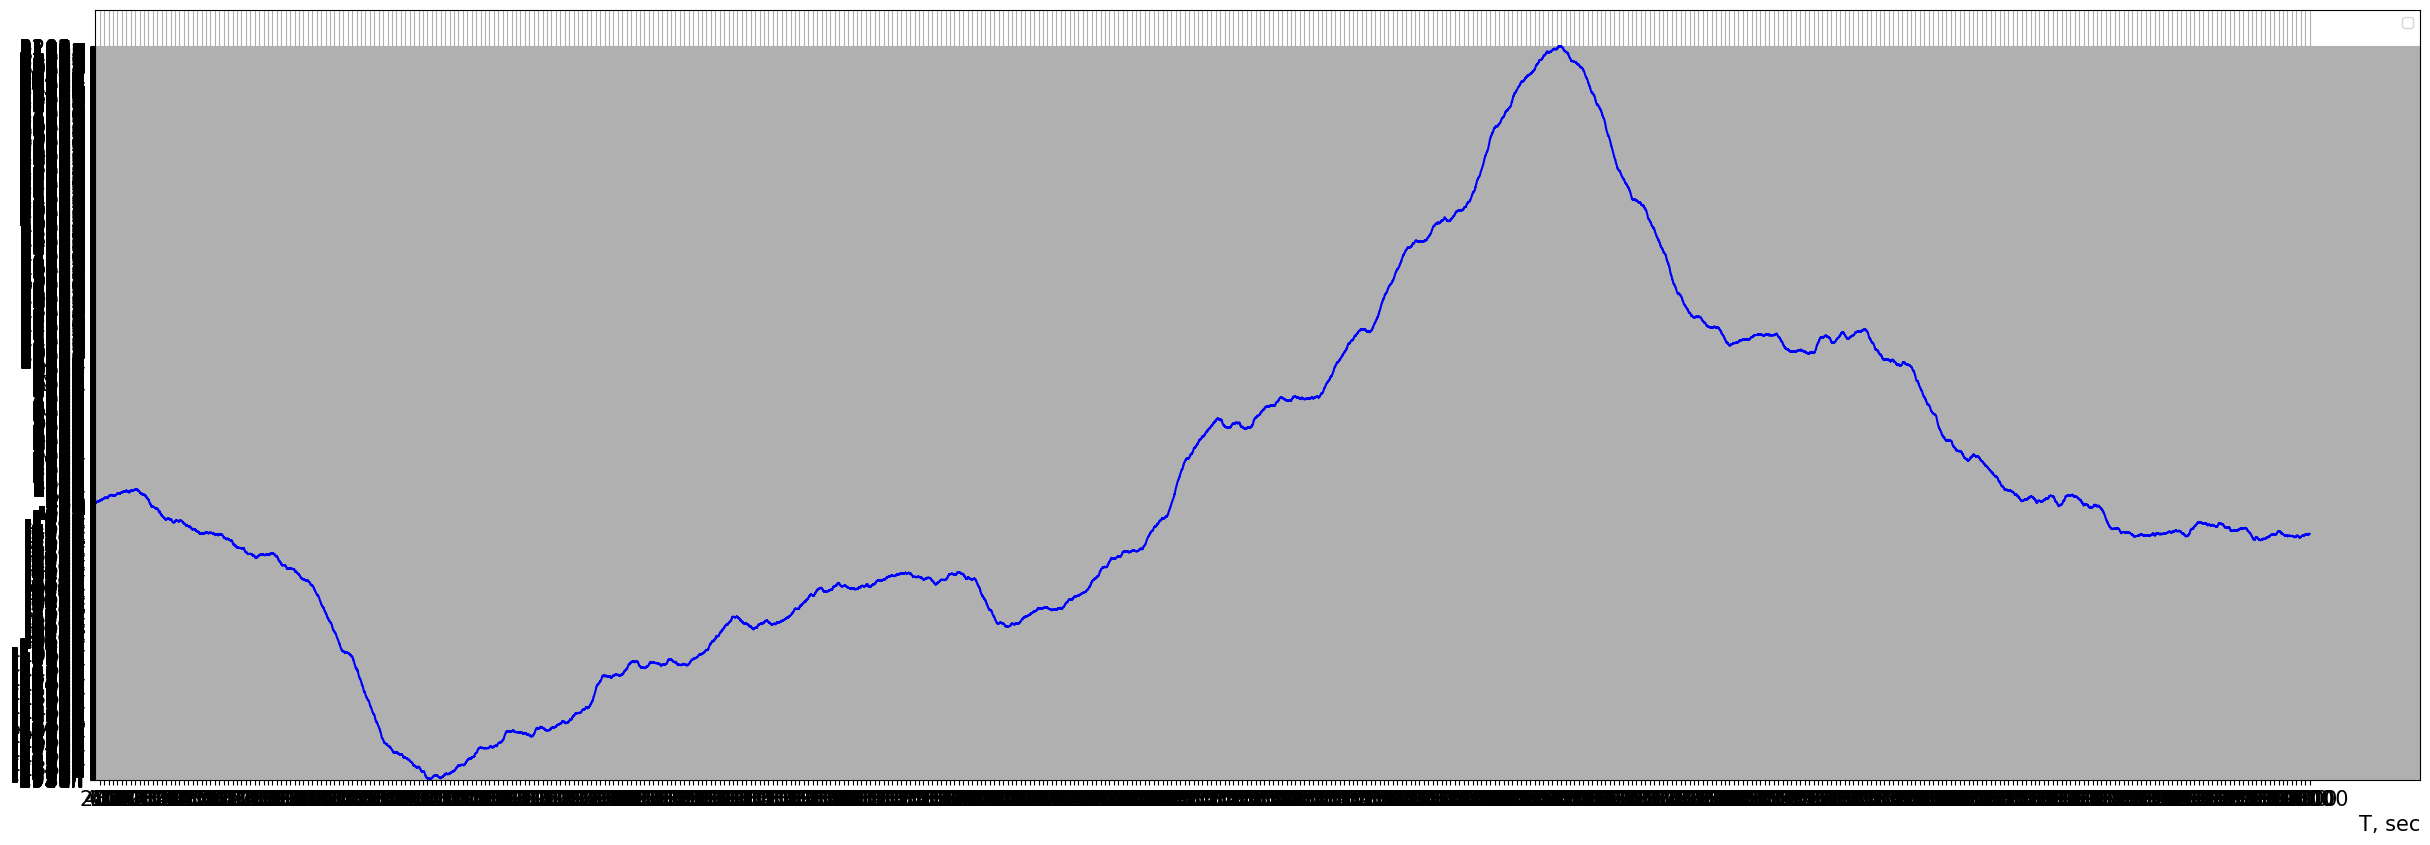

In [ ]:
print('Pink Noise: Plot #3')

bp = Binary_Telegraph_Process(LENGTH, pink_noise(LENGTH), RANDOM_SEED=[2])

fig = plot_ax(bp.get_data(), LENGTH)
plt.xlabel('T, sec', loc = 'right')
plt.ylabel('X')

plt.legend()
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.savefig('pink_noise_3.pdf')
pdf = matplotlib.backends.backend_pdf.PdfPages("pink_noise_3.pdf")

pdf.savefig( fig )
pdf.close()

plt.show()




Pink Noise: Plot #3


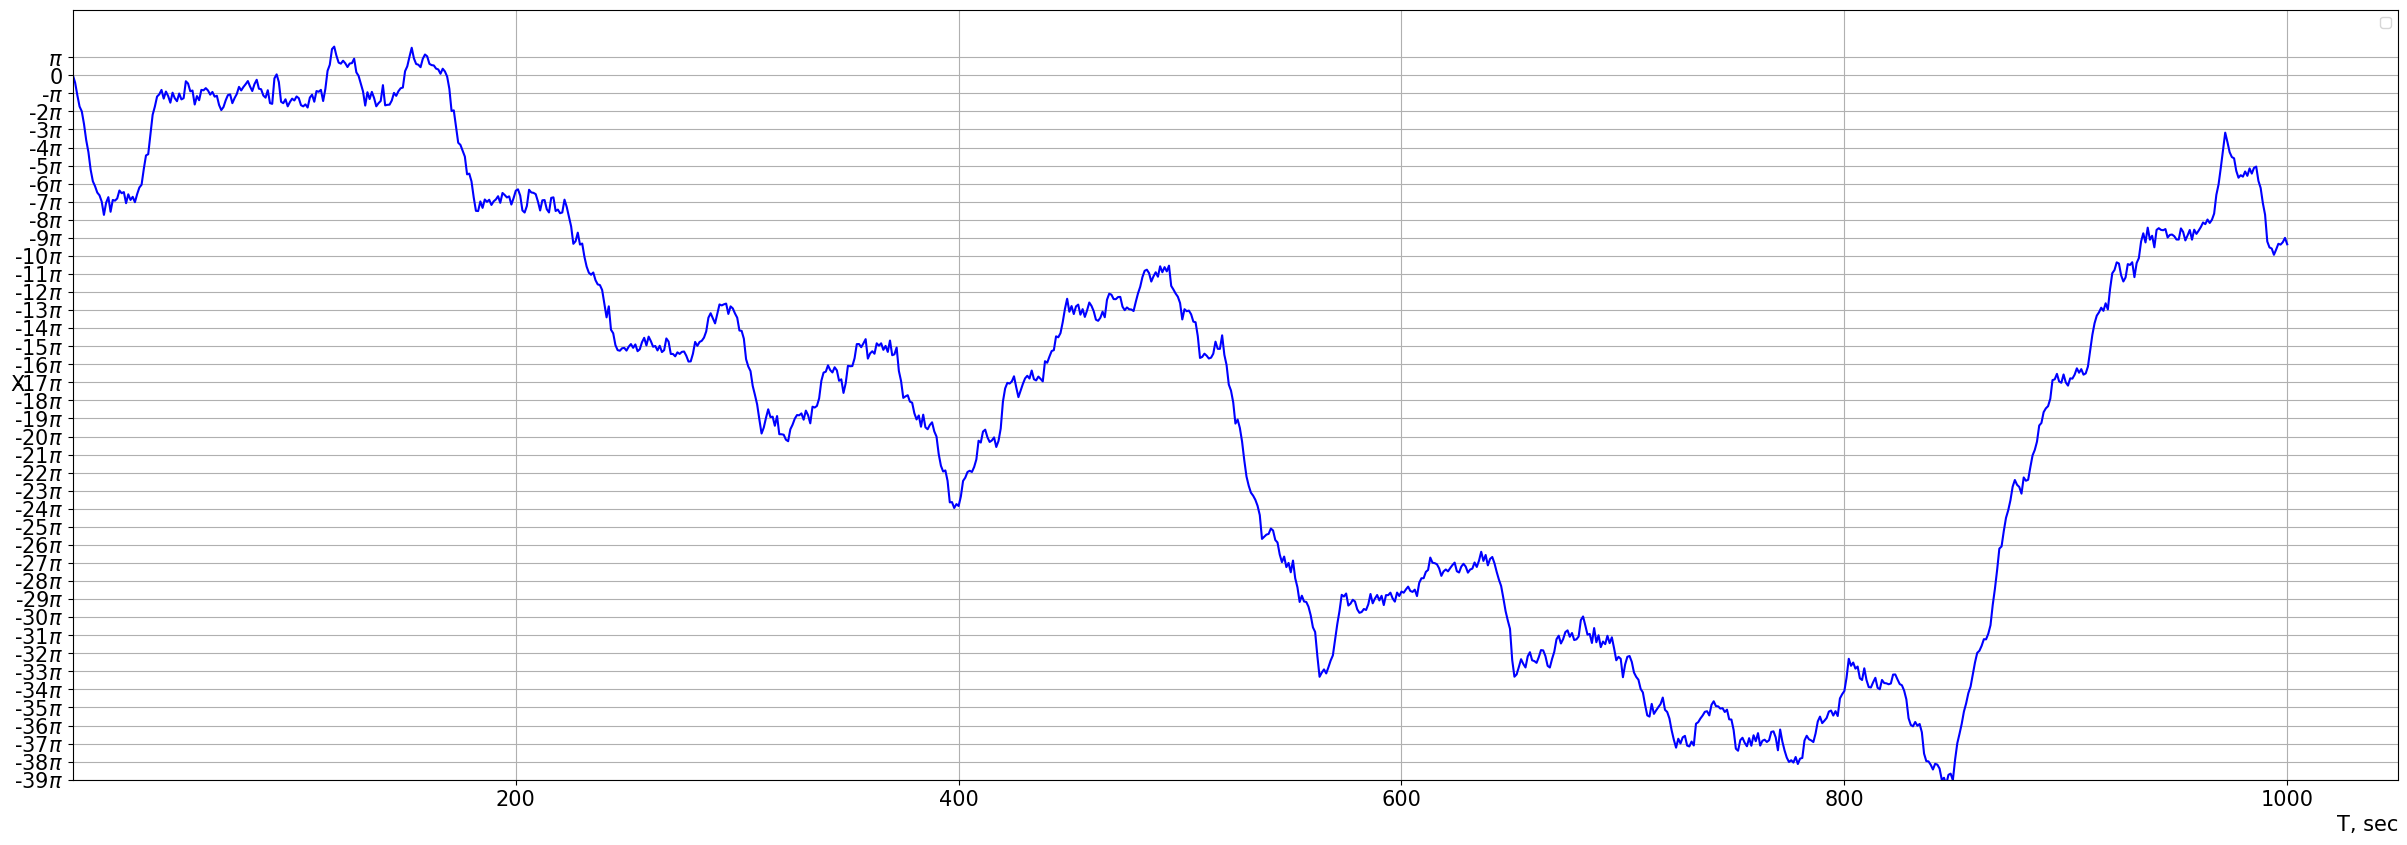

In [ ]:
print('Pink Noise: Plot #3')

bp = Binary_Telegraph_Process(length, pink_noise(length), RANDOM_SEED=[123])

fig = plot_ax(bp.get_data(), length)
plt.xlabel('T, sec', loc = 'right')
plt.ylabel('X')

plt.legend()
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.savefig('pink_noise_3.pdf')
pdf = matplotlib.backends.backend_pdf.PdfPages("pink_noise_3.pdf")

pdf.savefig( fig )
pdf.close()

plt.show()


Pink Noise: Plot #4


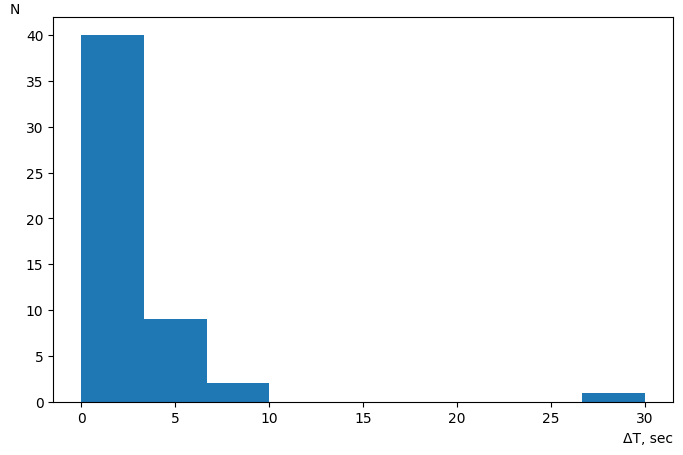

<Figure size 1500x1000 with 0 Axes>

In [ ]:
print('Pink Noise: Plot #4')

#bp = Binary_Telegraph_Process(length, pink_noise(length), RANDOM_SEED=[133])
clusters = bp.clusters()
deltas = get_deltas(bp.clusters())
df = pd.DataFrame(deltas)

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(deltas,len(df.value_counts()))
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
plt.figure(figsize = (15,10))

# plt.savefig('pink_noise_4.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("pink_noise_4.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()

In [ ]:
pd.set_option('display.max_rows', 500)
clusters.head(300)

,INIT,LABEL
0,0.000003,0.000000
1,-4.696043,-3.141593
2,-5.916409,-6.283185
3,-5.519115,-6.283185
4,-4.821590,-6.283185
5,-4.350019,-3.141593
6,-5.196273,-6.283185
7,-2.943979,-3.141593
8,-2.211160,-3.141593
9,-3.096768,-3.141593


In [ ]:
s = 0
c_o  = 0
for i in range(len(deltas)):
  print(deltas[i])
  s += deltas[i]

In [ ]:
#LENGTH = 10
bp = Binary_Telegraph_Process(LENGTH, pink_noise(LENGTH), RANDOM_SEED=[2])
clusters = bp.clusters()

In [ ]:
clusters

,INIT,LABEL
0,0.000003,0.000000
1,-0.083030,0.000000
2,0.279248,0.000000
3,-1.461708,0.000000
4,-2.333768,-3.141593
...,...,...
99996,17.049200,9.424778
99997,15.180337,9.424778
99998,14.592102,9.424778
99999,13.361467,9.424778


In [ ]:
for LABEL in clusters:
    print(clusters[LABEL].unique())

[ 3.14159265e-06 -8.30303200e-02  2.79247769e-01 ...  1.45921016e+01
  1.33614668e+01  1.20679488e+01]
[ 0.         -3.14159265 -6.28318531 -9.42477796  6.28318531  3.14159265
  9.42477796]


Plot #1


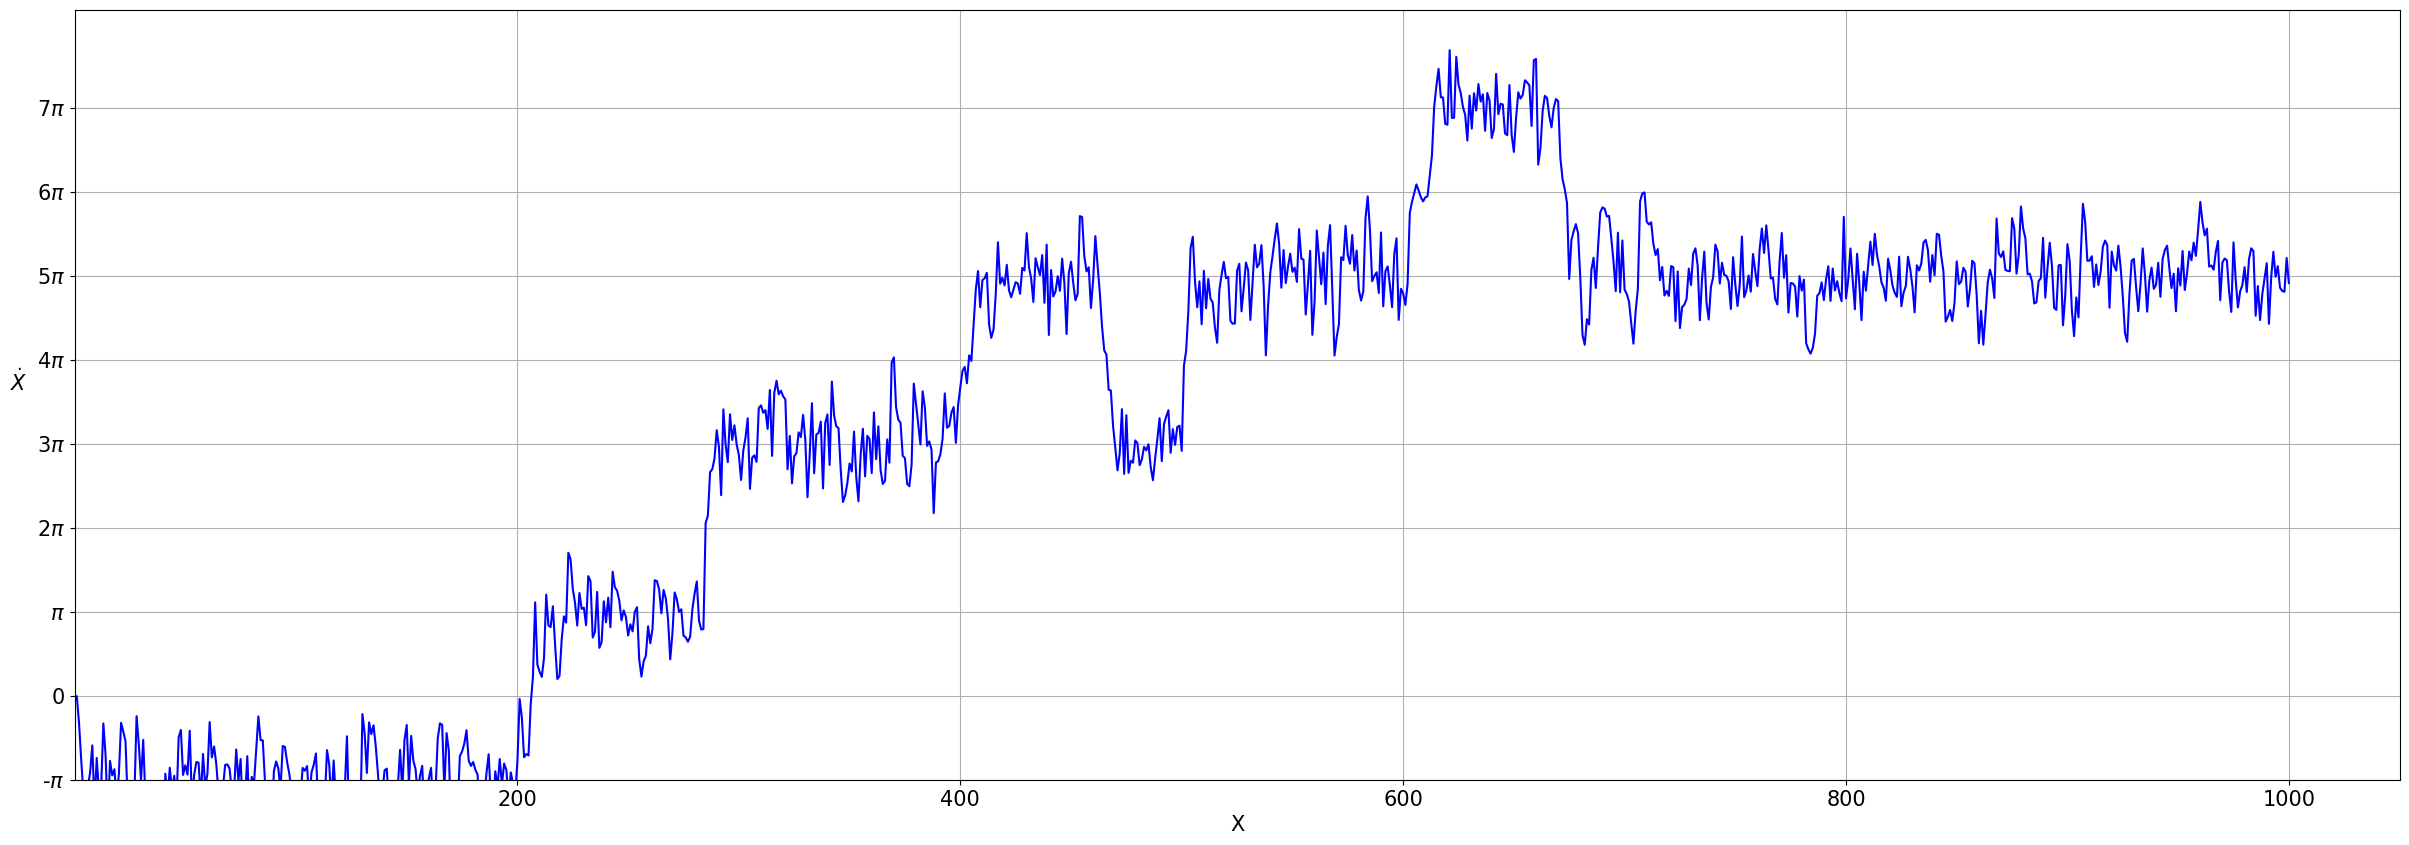

Plot #2


<Figure size 640x480 with 0 Axes>

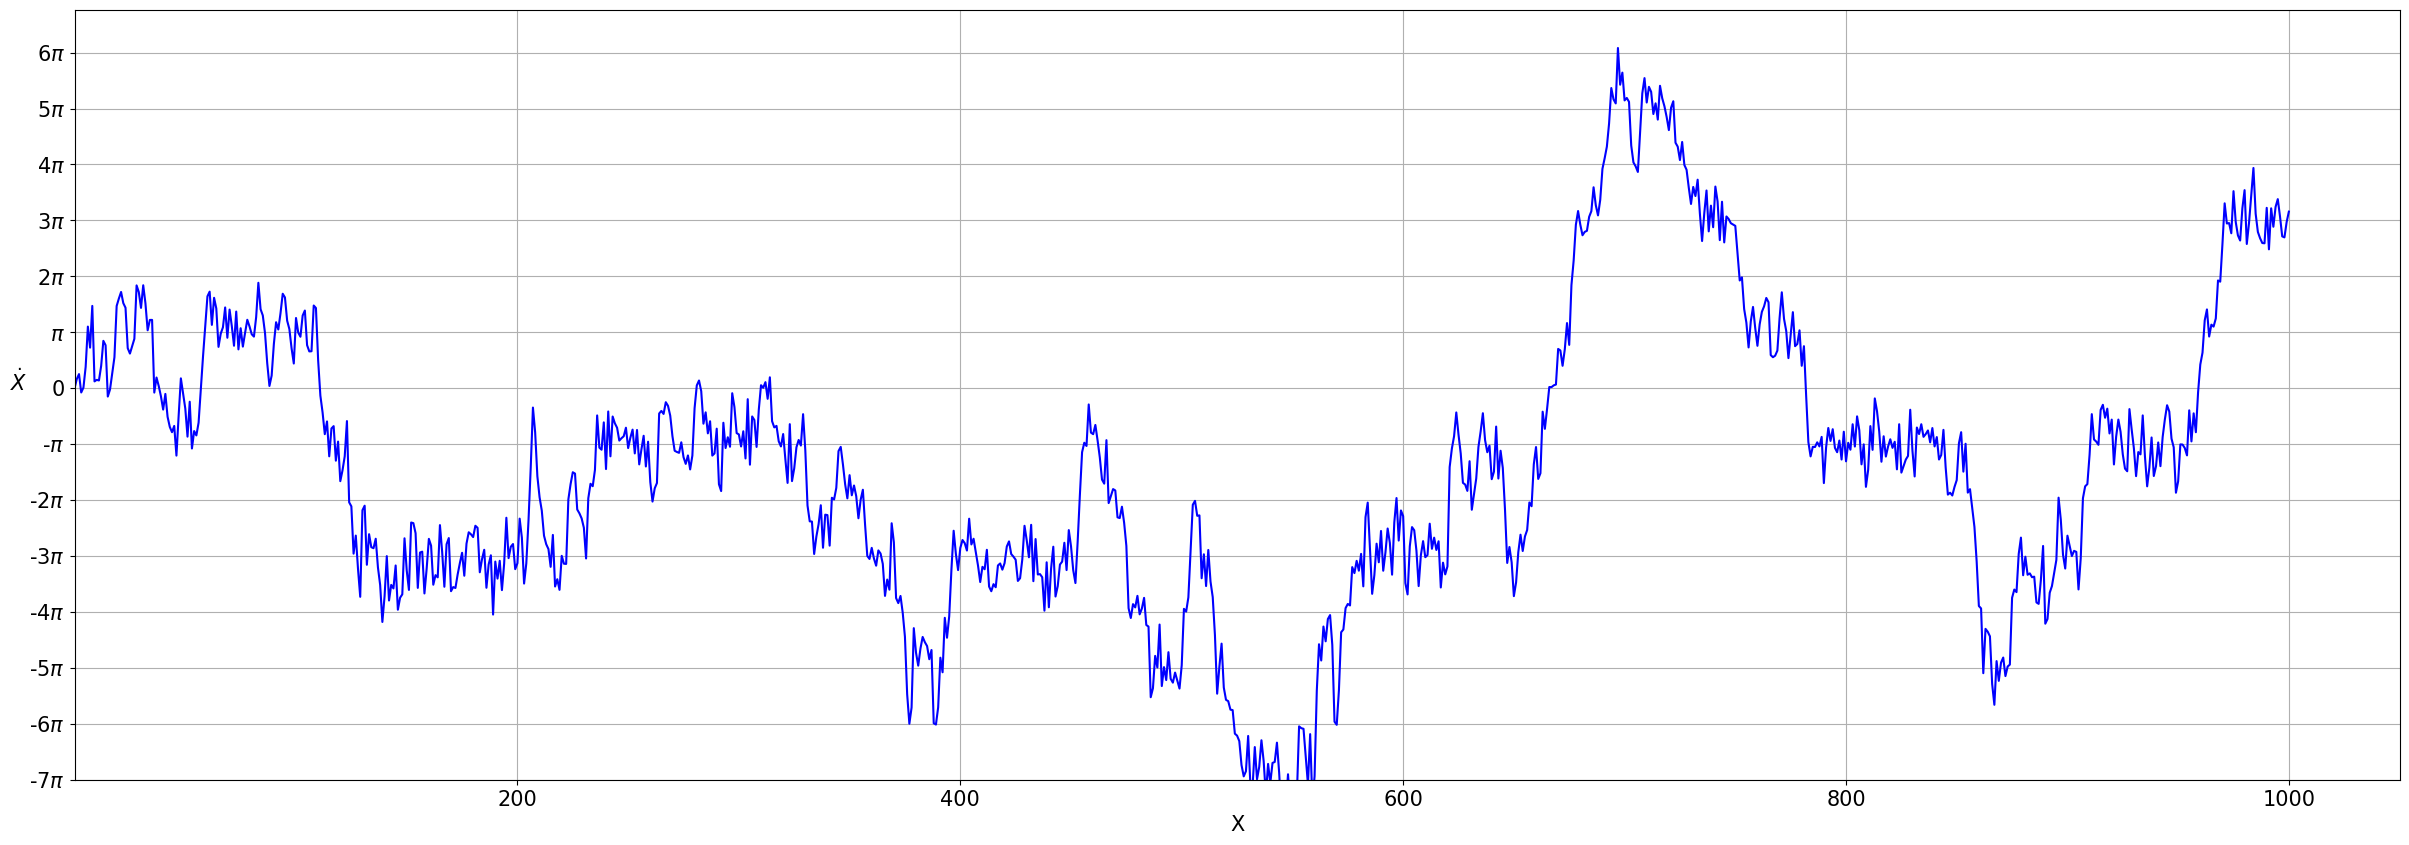

Pink Noise: Plot #3


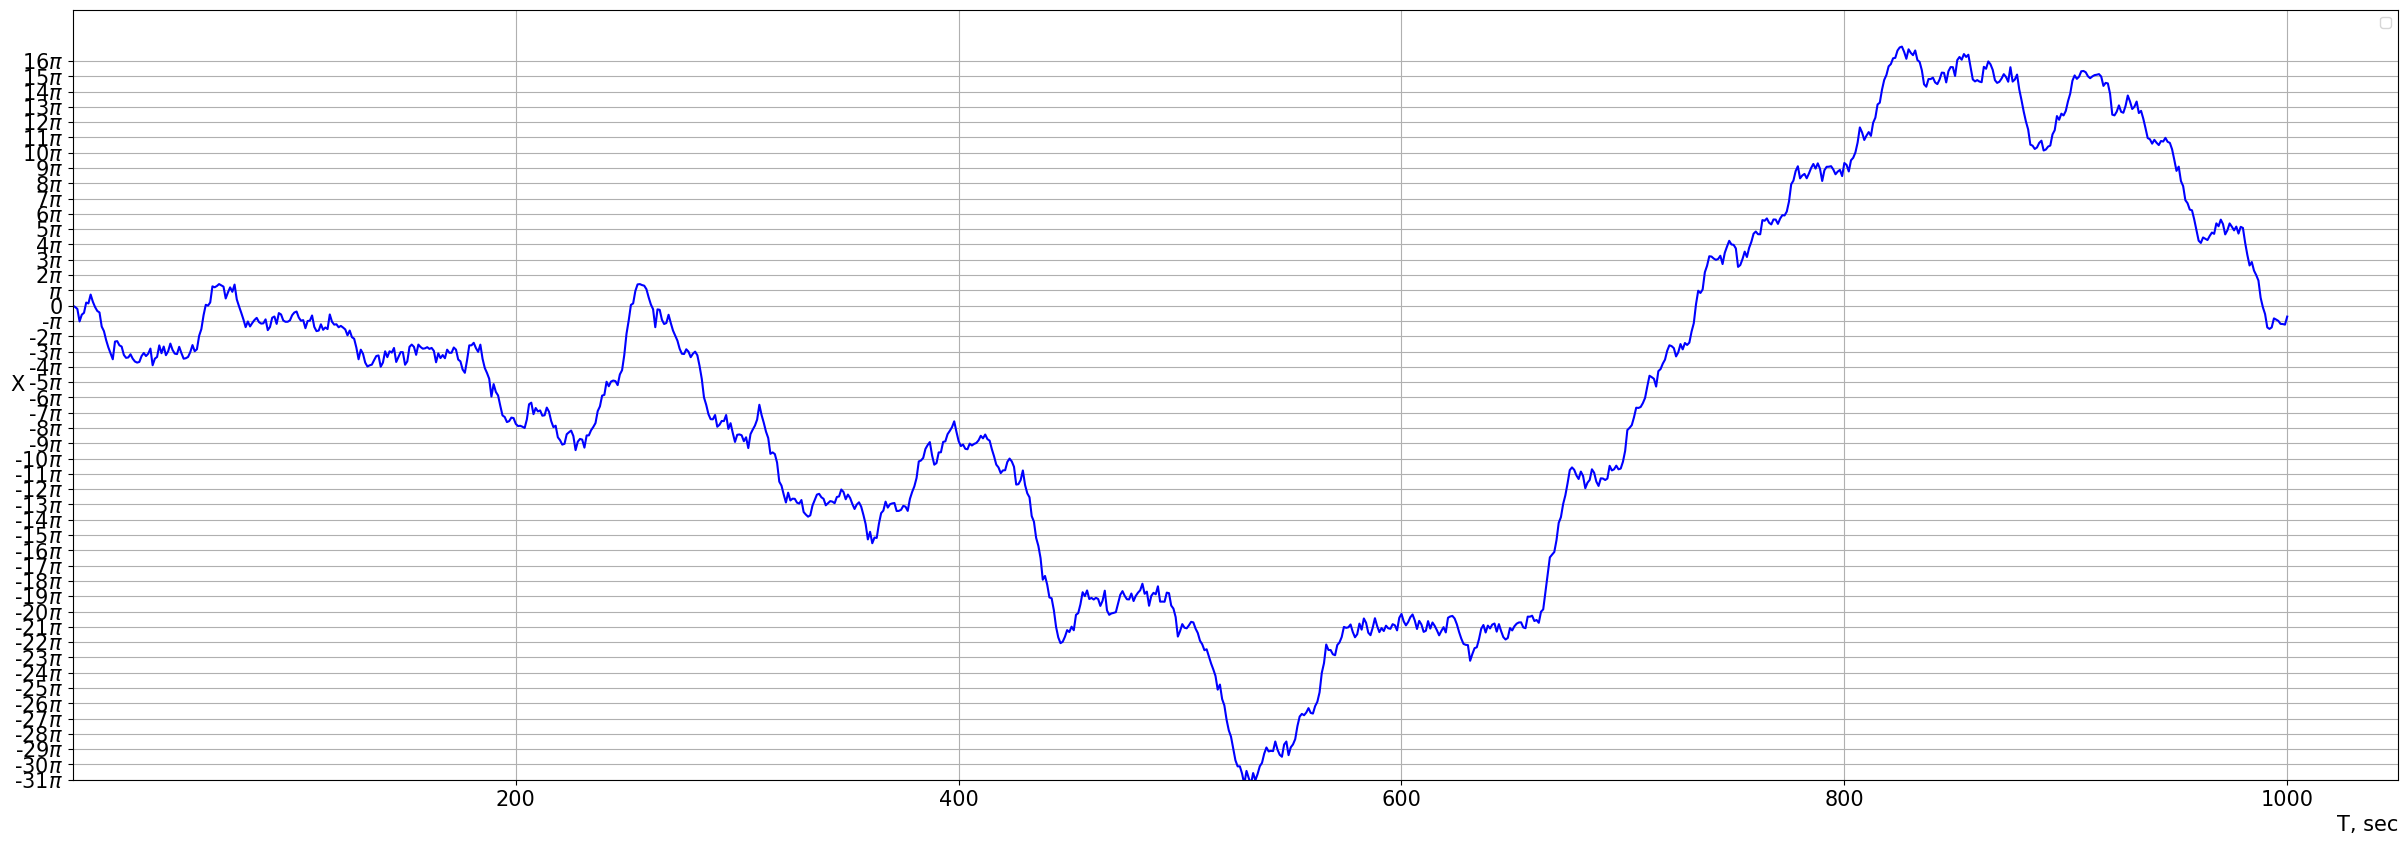

Pink Noise: Plot #4


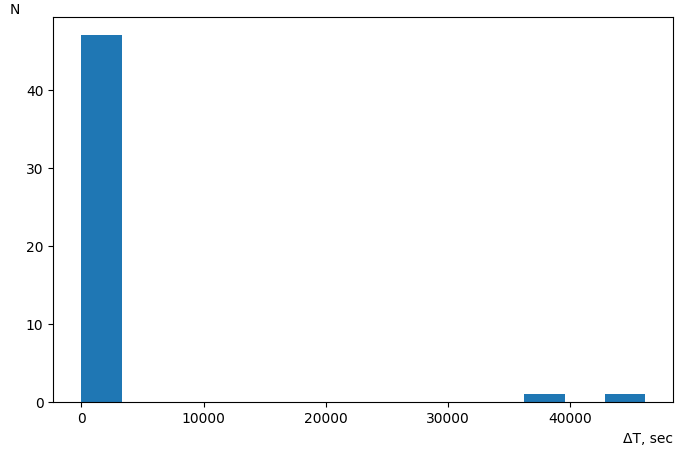

<Figure size 1500x1000 with 0 Axes>

Blue Noise: Plot #3


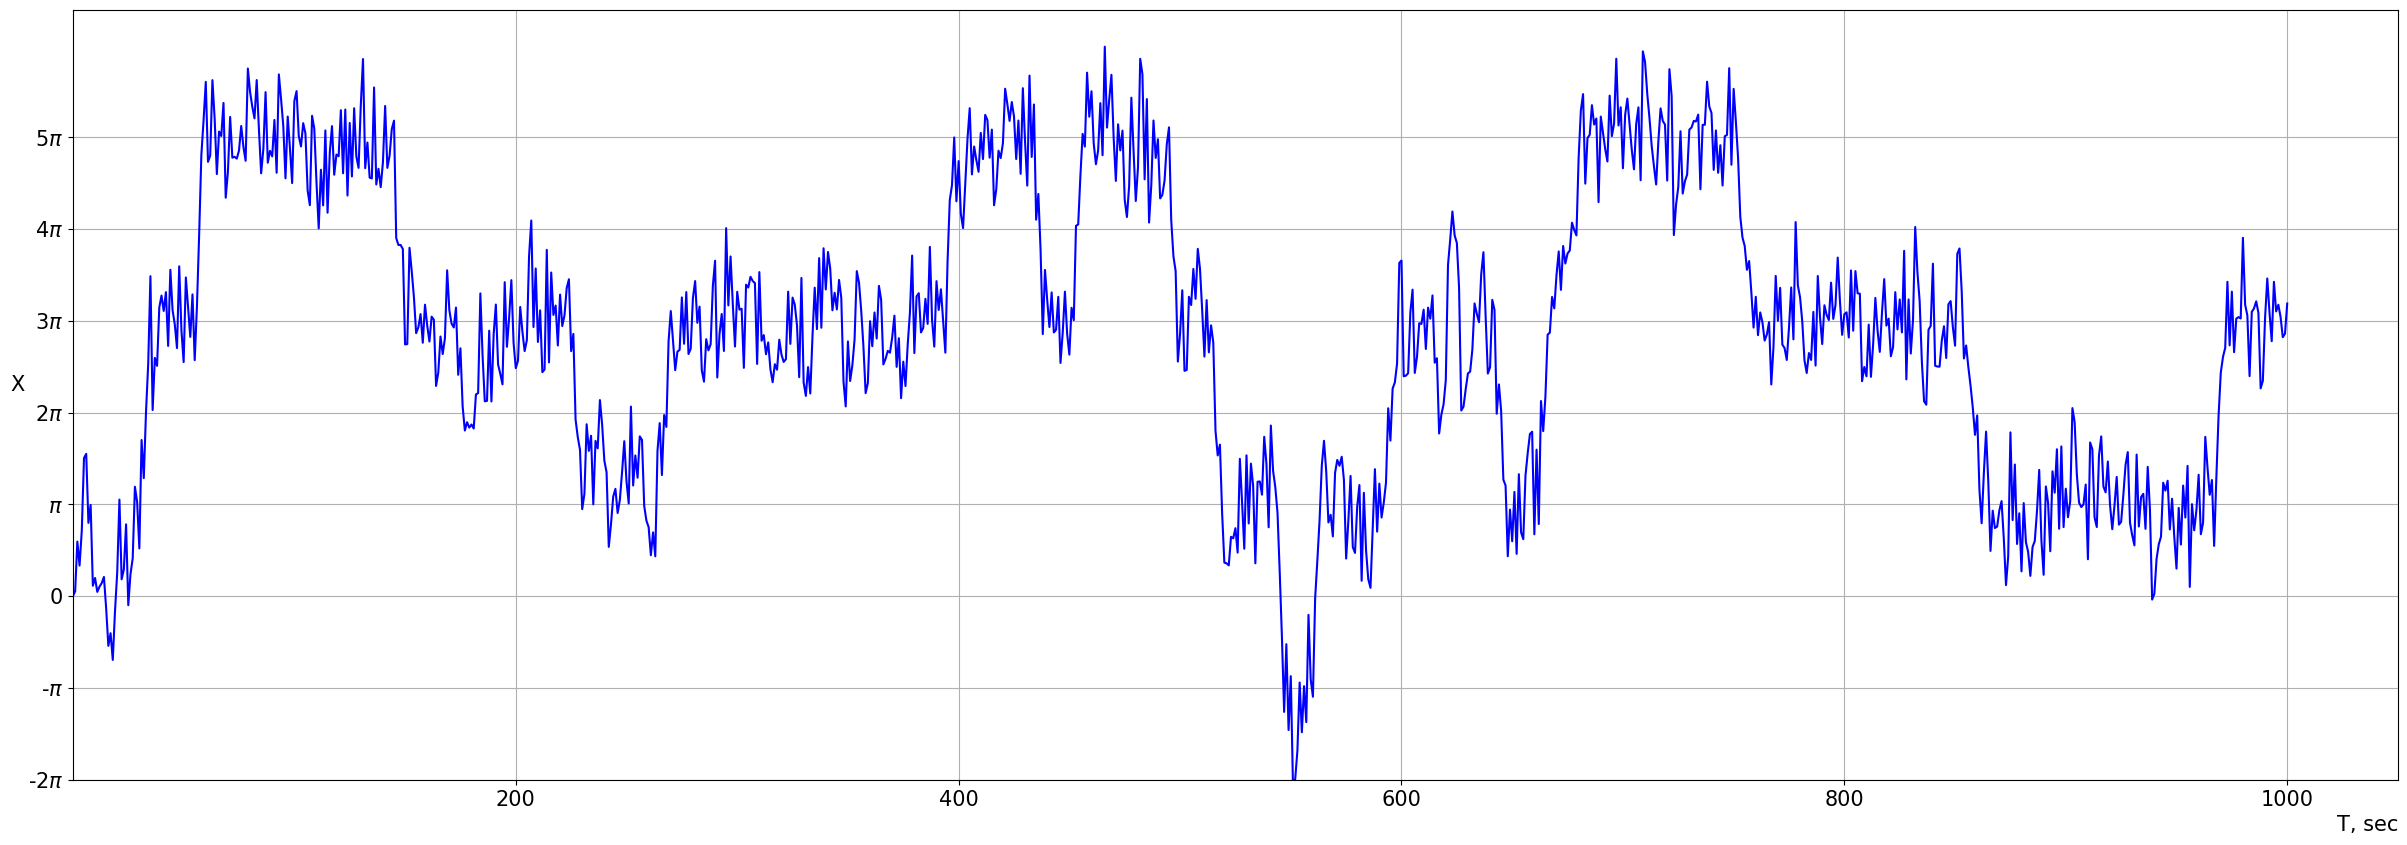

Blue Noise: Plot #4


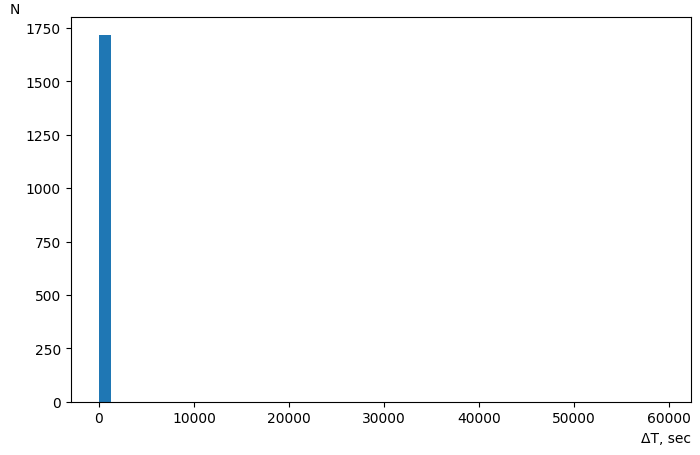

<Figure size 1500x1000 with 0 Axes>

Brown Noise: Plot #3


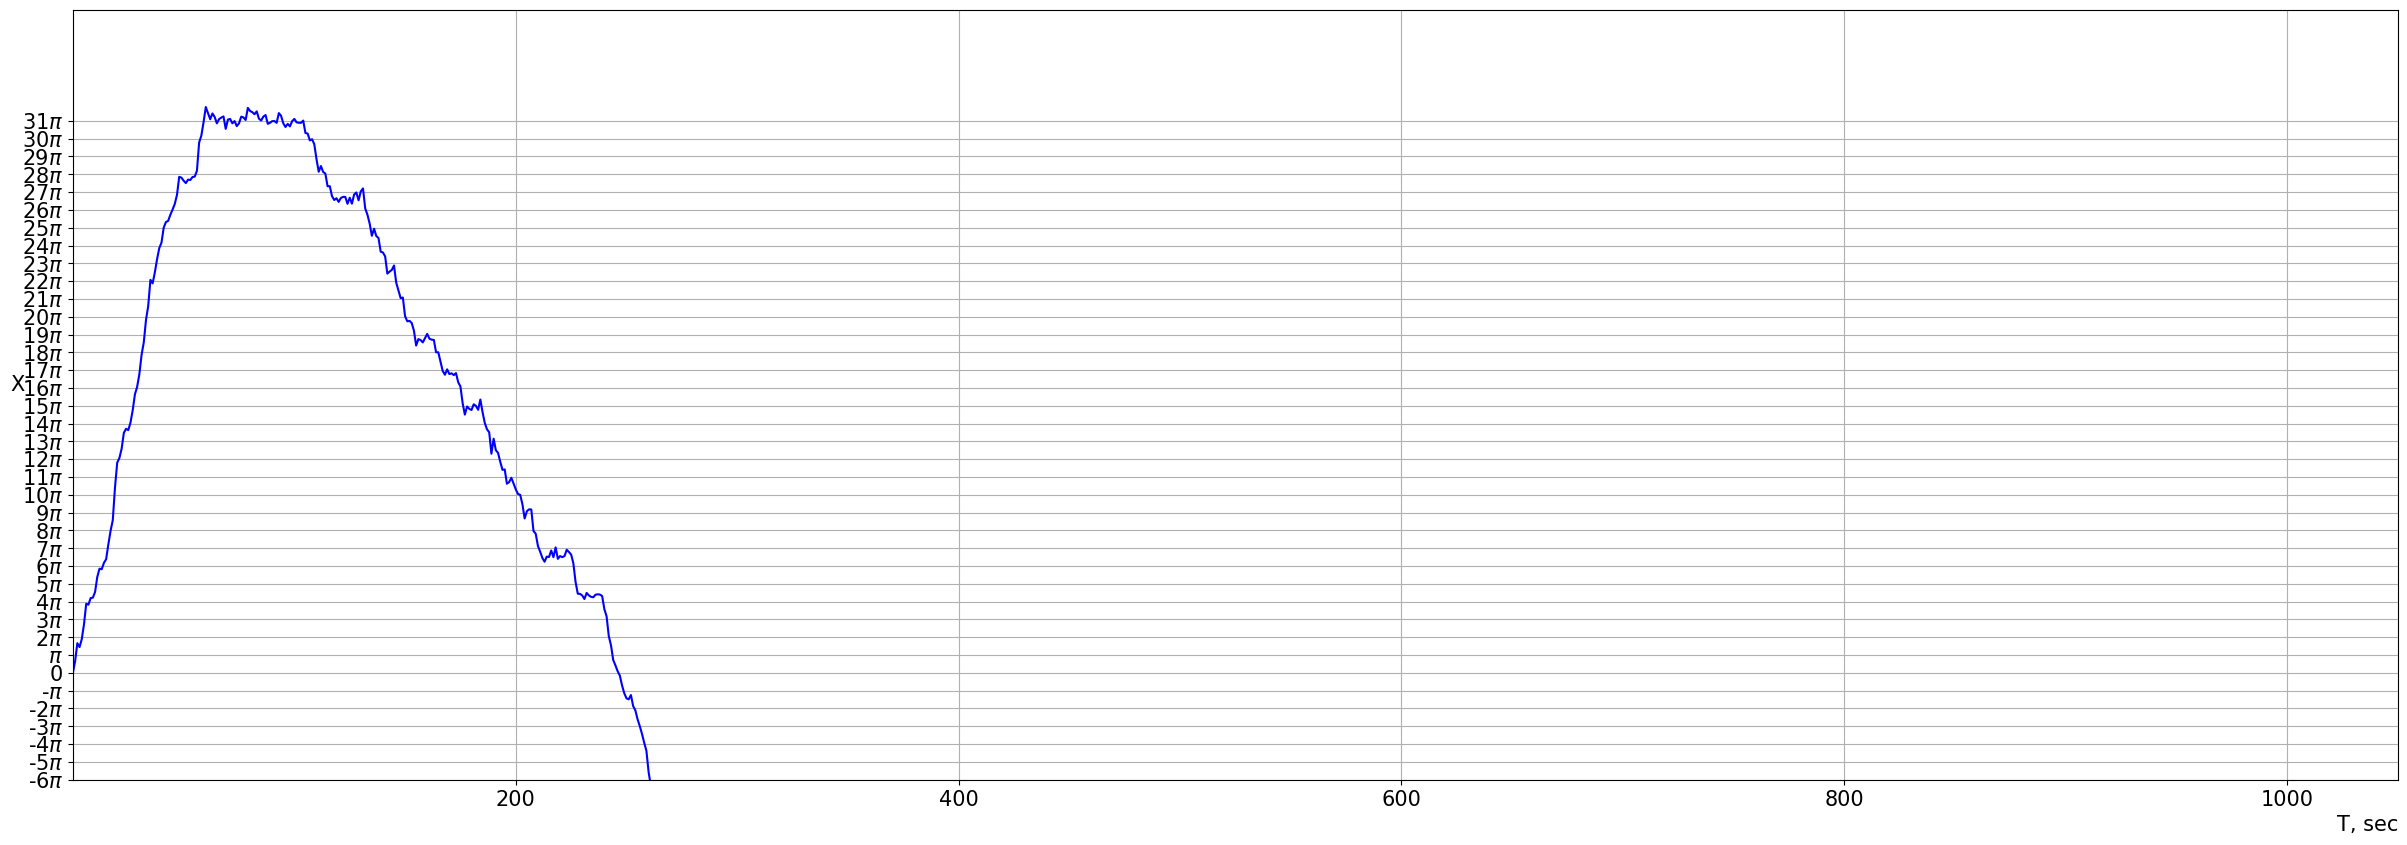

Brown Noise: Plot #4


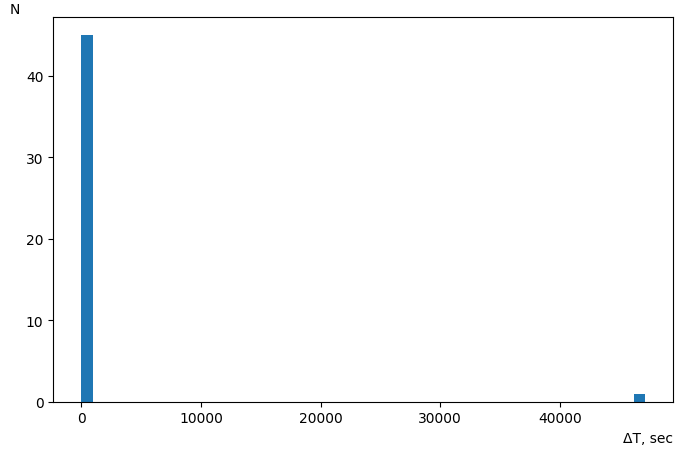

<Figure size 1500x1000 with 0 Axes>

Violet Noise: Plot #3


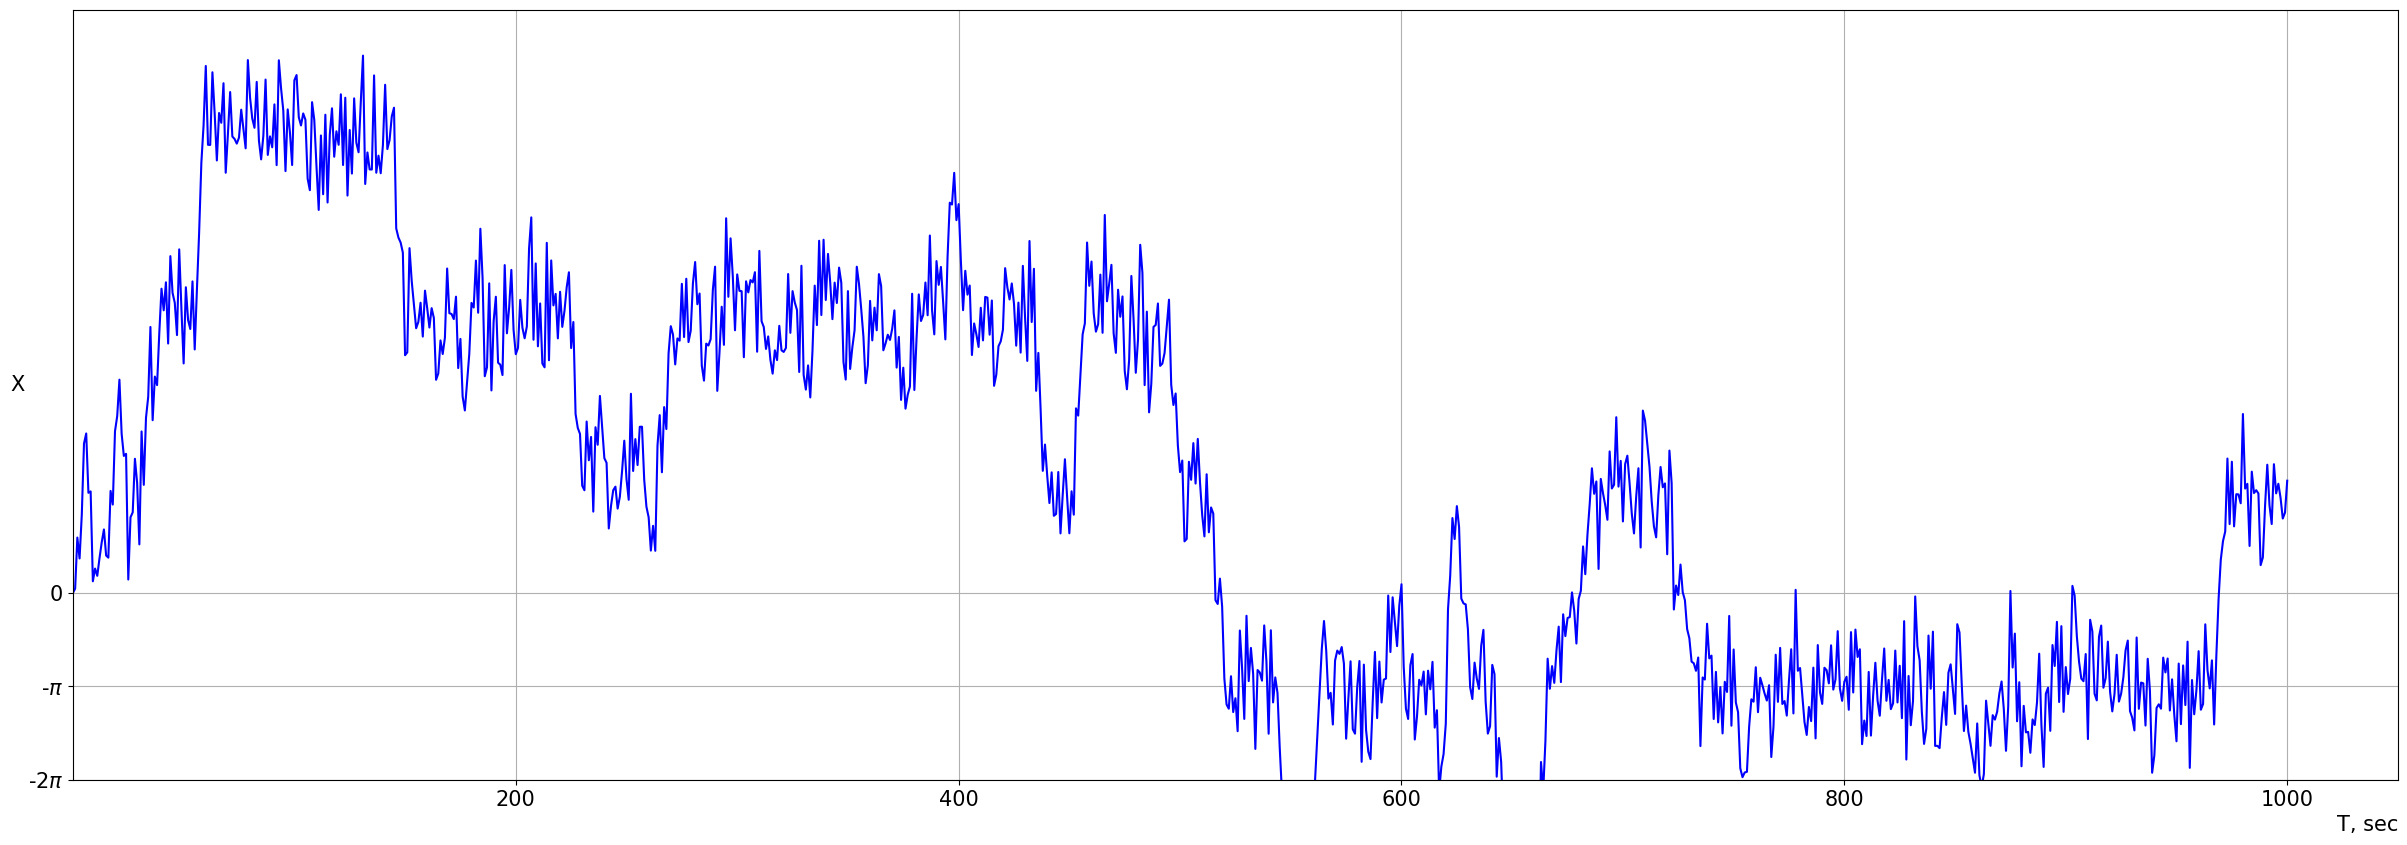

Violet Noise: Plot #4
       0
0      1
1      0
2      0
3      1
4      0
5      0
6      0
7      4
8      0
9      1
10     1
11     0
12     7
13     0
14     1
15     1
16     0
17     1
18     0
19     3
20     0
21     5
22     0
23     1
24     0
25     0
26     3
27     1
28     2
29     0
30    10
31     0
32     7
33     0
34     3
35     0
36     4
37     0
38     4
39     0
40     8
41     2
42     6
43     0
44     1
45     0
46     0
47     0
48     0
49     1
50     0
51     0
52     0
53     2
54     3
55     0
56     1
57     0
58     2
59     4
60     0
61     2
62    39
63     0
64     9
65     2
66     6
67     0
68     5
69     1
70    15
71     0
72    21
73     1
74     0
75     1
76    11
77     1
78     9
79     0
80     2
81     0
82     5
83     0
84     0
85     1
86     0
87     1
88   385
89     0
90     0
91     0
92     0
93     1
94     3
95     0
96     0
97     0
98    22
99     0
100    2
101    0


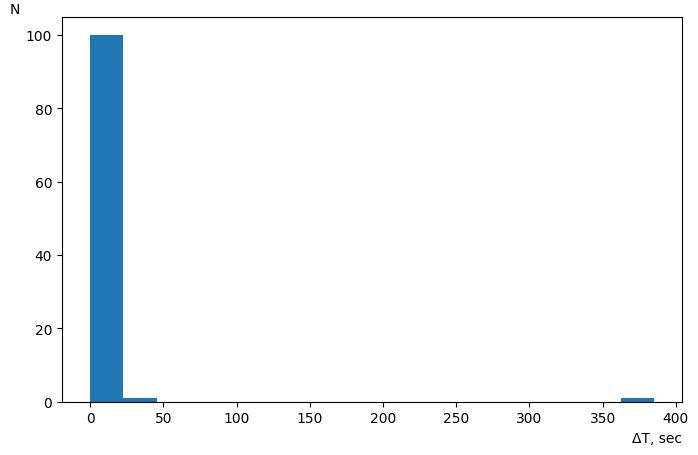

<Figure size 1500x1000 with 0 Axes>

White Noise: Plot #3


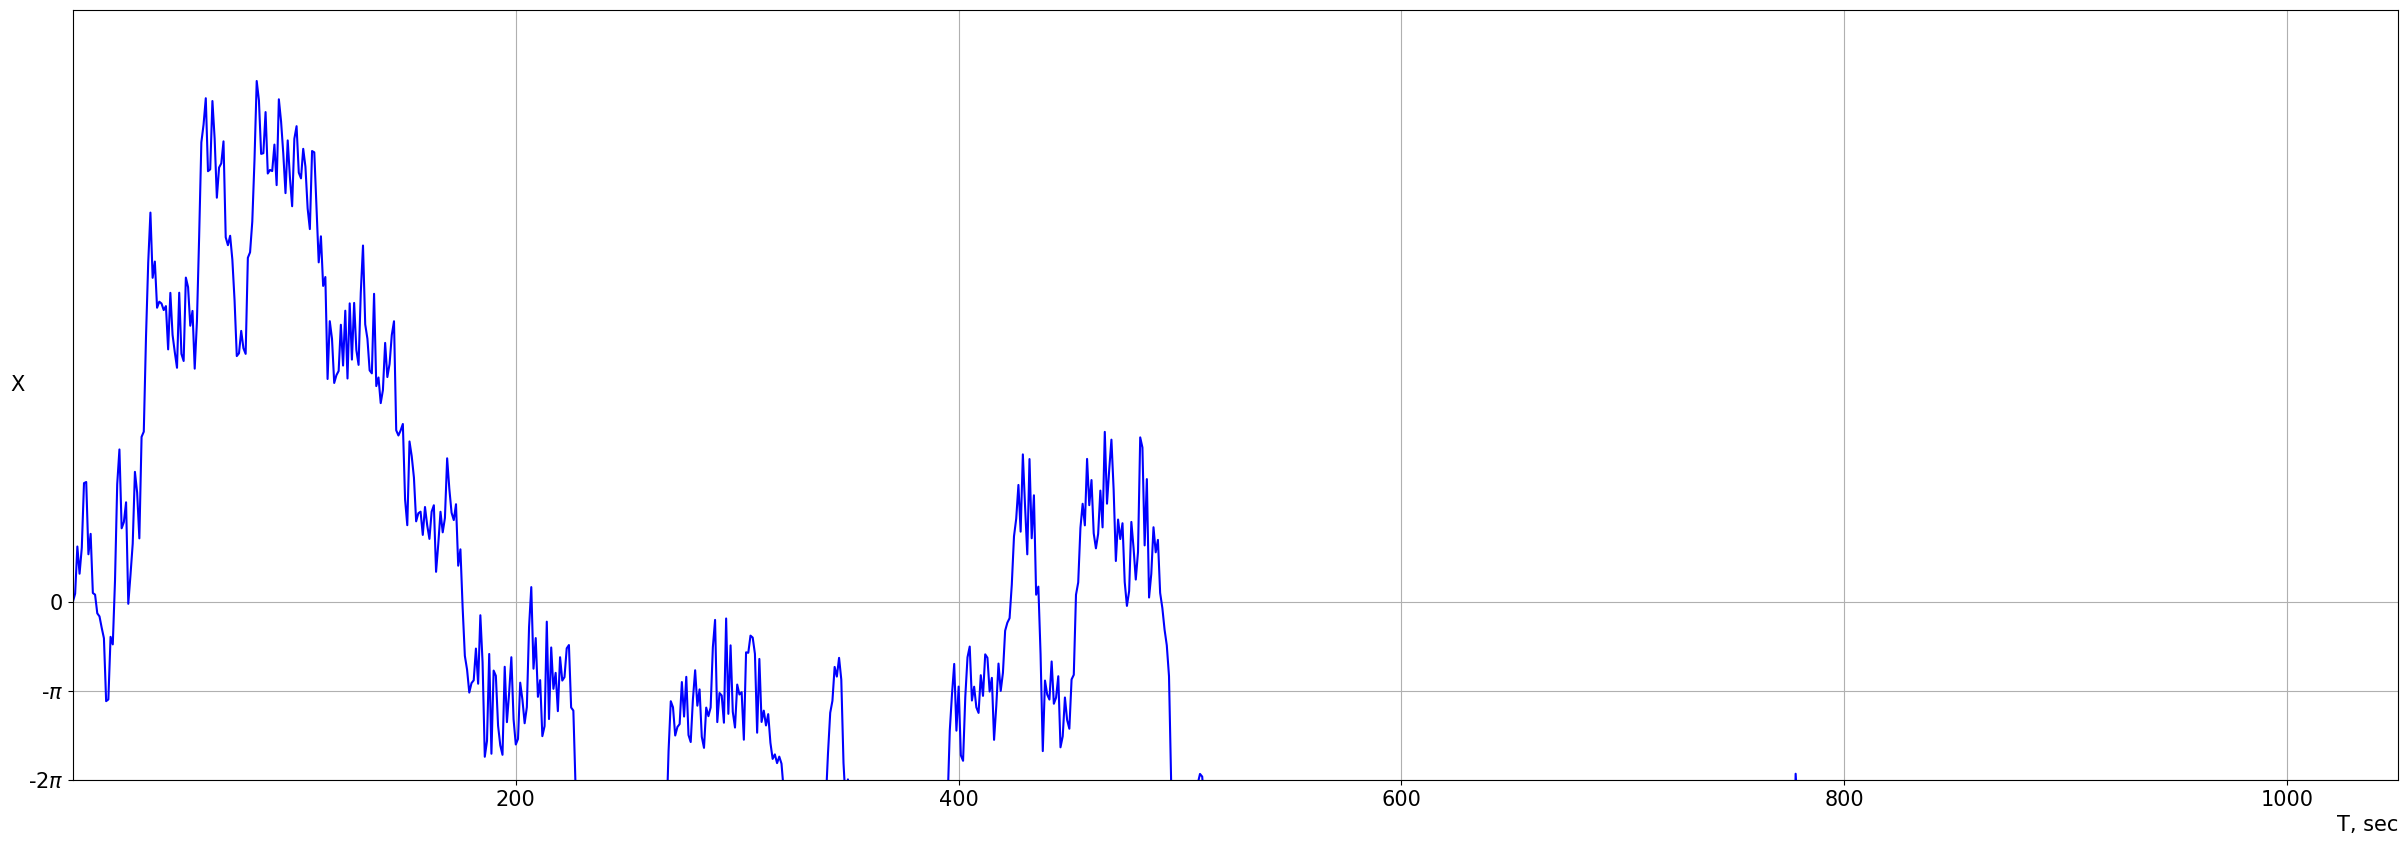

White Noise: Plot #4
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 33, 34, 35, 52, 58, 59, 68, 76, 85, 86, 96, 111, 211, 232, 383, 442, 884, 2778, 5427, 5769, 7776, 41016]


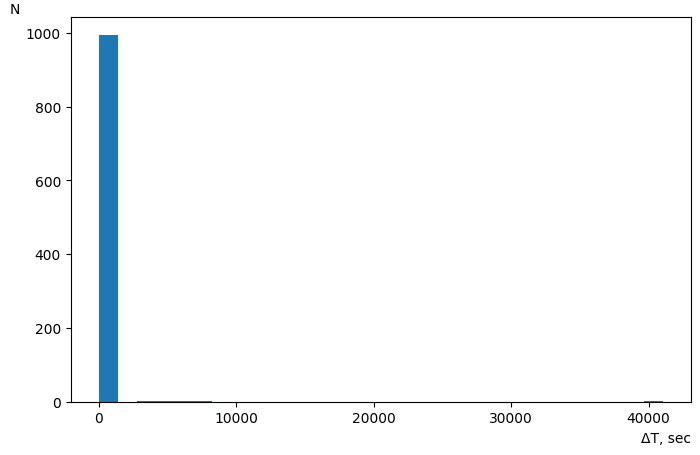

<Figure size 1500x1000 with 0 Axes>

ECG: Plot #3


FileNotFoundError: ignored

In [ ]:
length = 1_000
LENGTH = 100_000
figures = []

print('Plot #1')

bp = Binary_Telegraph_Process(length, np.random.normal, 0, 1, RANDOM_SEED=[2], no_error=True)

fig = plot_ax(bp.get_data(), length)
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.ylabel(r'$\dot{X}$')
plt.xlabel('X')

plt.show()

plt.savefig('plot_1.pdf')
pdf = matplotlib.backends.backend_pdf.PdfPages("plot_1.pdf")

pdf.savefig( fig )
pdf.close()



print('Plot #2')

bp = Binary_Telegraph_Process(length, np.random.normal, 0, 1, RANDOM_SEED=[2])

fig = plot_ax(bp.get_data(), length)

#plt.legend(loc = 'upper right', fontsize = 18)
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.xlabel('X')
plt.ylabel(r'$\dot{X}$')

plt.savefig('plot_2.pdf')
pdf = matplotlib.backends.backend_pdf.PdfPages("plot_2.pdf")

pdf.savefig( fig )
pdf.close()
plt.show()
#
#
#
print('Pink Noise: Plot #3')

bp = Binary_Telegraph_Process(length, pink_noise(length), RANDOM_SEED=[2])

fig = plot_ax(bp.get_data(), length)
plt.xlabel('T, sec', loc = 'right')
plt.ylabel('X')

plt.legend()
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.savefig('pink_noise_3.pdf')
pdf = matplotlib.backends.backend_pdf.PdfPages("pink_noise_3.pdf")

pdf.savefig( fig )
pdf.close()

plt.show()


print('Pink Noise: Plot #4')

bp = Binary_Telegraph_Process(LENGTH, pink_noise(LENGTH), RANDOM_SEED=[2])
clusters = bp.clusters()
deltas = get_deltas(bp.clusters())
df = pd.DataFrame(deltas)

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(deltas,len(df.value_counts()))
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
plt.figure(figsize = (15,10))

# plt.savefig('pink_noise_4.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("pink_noise_4.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()


print('Blue Noise: Plot #3')

bp = Binary_Telegraph_Process(length, blue_noise(length), RANDOM_SEED=[2])

fig = plot_ax(bp.get_data(), length)

plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.ylabel('X')
plt.xlabel('T, sec', loc = 'right')

# plt.savefig('blue_noise_3.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("blue_noise_3.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()



print('Blue Noise: Plot #4')

bp = Binary_Telegraph_Process(LENGTH, blue_noise(LENGTH), RANDOM_SEED=[2])
deltas_bl = get_deltas(bp.clusters())

df = pd.DataFrame(deltas_bl)
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(deltas_bl,len(df.value_counts()))
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
plt.figure(figsize = (15,10))

# plt.savefig('blue_noise_4.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("blue_noise_4.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()


print('Brown Noise: Plot #3')

bp = Binary_Telegraph_Process(length, brownian_noise(length), RANDOM_SEED=[2])

fig = plot_ax(bp.get_data(), length)

plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)

plt.xlabel('T, sec', loc = 'right')
plt.ylabel('X')
plt.ylim(-6*np.pi)

# plt.savefig('brownian_noise_3.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("brownian_noise_3.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()


print('Brown Noise: Plot #4')

bp = Binary_Telegraph_Process(LENGTH, brownian_noise(LENGTH), RANDOM_SEED=[2])
deltas_brn = get_deltas(bp.clusters())
df = pd.DataFrame(deltas_brn)

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(deltas_brn,50)
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
plt.figure(figsize = (15,10))

# plt.savefig('brownian_noise_4.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("brownian_noise_4.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()


print('Violet Noise: Plot #3')

bp = Binary_Telegraph_Process(length, violet_noise(length), RANDOM_SEED=[2])

fig = plot_ax(bp.get_data(), length)

plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)

plt.xlabel('T, sec', loc = 'right')
plt.ylabel('X')
plt.ylim(-2*np.pi)
plt.yticks([0,-np.pi, -2*np.pi], ['0','-$\pi$', '-2$\pi$'])

# plt.savefig('violet_noise_3.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("violet_noise_3.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()


print('Violet Noise: Plot #4')

bp = Binary_Telegraph_Process(LENGTH, violet_noise(LENGTH), RANDOM_SEED=[2])
deltas_vn = get_deltas(bp.clusters())

df = pd.DataFrame(deltas_vn)
print(df)
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(deltas_vn,len(df.value_counts()))
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
plt.figure(figsize = (15,10))

# plt.savefig('violet_noise_4.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("violer_noise_4.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()


print('White Noise: Plot #3')

bp = Binary_Telegraph_Process(length, white_noise(length), RANDOM_SEED=[2])

fig = plot_ax(bp.get_data(), length)

plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)

plt.xlabel('T, sec', loc = 'right')
plt.ylabel('X')
plt.ylim(0)
plt.yticks([0,-np.pi, -2*np.pi], ['0','-$\pi$','-2$\pi$'])

# plt.savefig('white_noise_3.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("white_noise_3.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()



print('White Noise: Plot #4')

bp = Binary_Telegraph_Process(LENGTH, white_noise(LENGTH), RANDOM_SEED=[2])
deltas_whn = get_deltas(bp.clusters())

df = pd.DataFrame(deltas_whn)
print(list(np.unique(df[0])))
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(list(deltas_whn), bins = 30)
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
plt.figure(figsize = (15,10))

# plt.savefig('white_noise_4.pdf')
# pdf = matplotlib.backends.backend_pdf.PdfPages("white_noise_4.pdf")

# pdf.savefig( fig )
# pdf.close()

plt.show()

print('ECG: Plot #3')


def make_data_ecg3(errors):
        np.random.seed(12)
        data = []
        i = 0
        x_t = np.pi/1e6
        data.append(x_t)
        #errors = self.errors()
        errors -= np.mean(errors)
        errors /= np.std(errors)
        while i < errors.size:
            x_t = x_t + math.sin(x_t) + errors[i]
            data.append(x_t)
            i += 1
        return data

#bp = Binary_Telegraph_Process(length, None, 'ECG', RANDOM_SEED=[2])



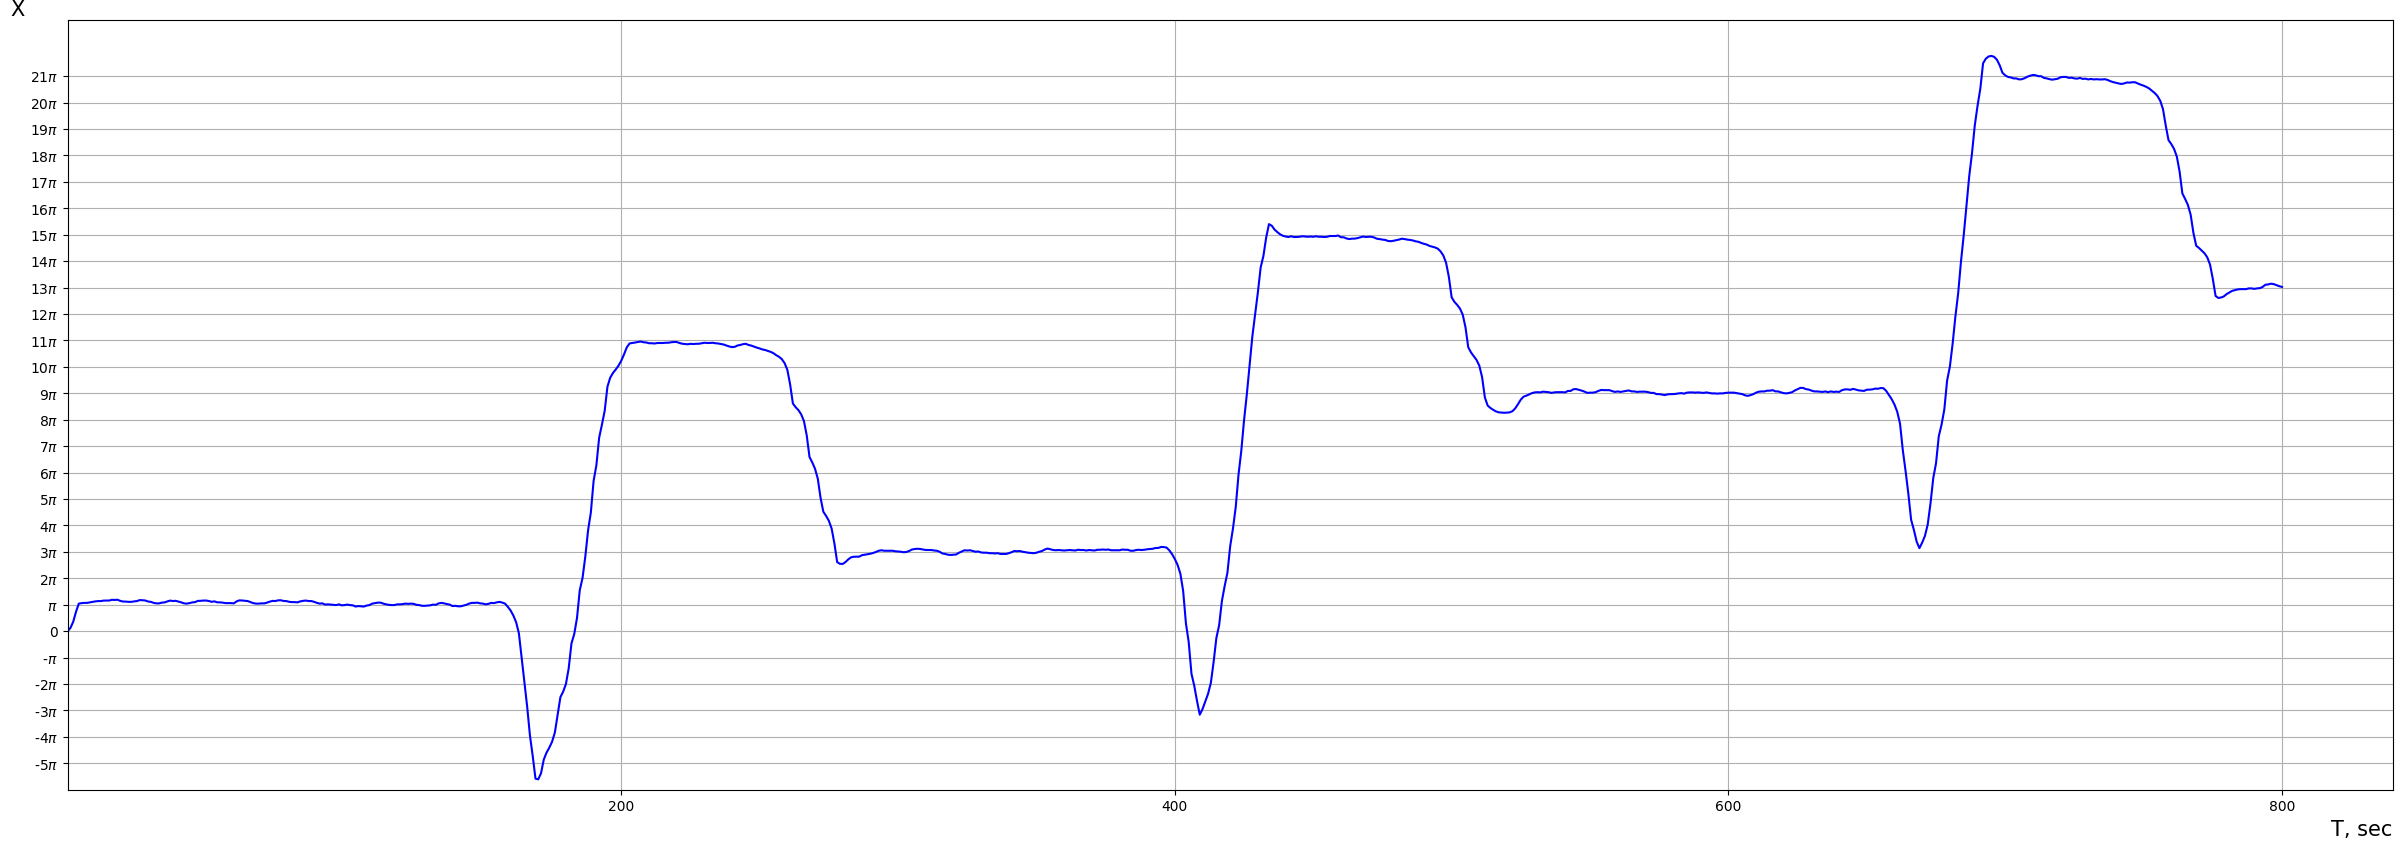

ECG: Plot #4


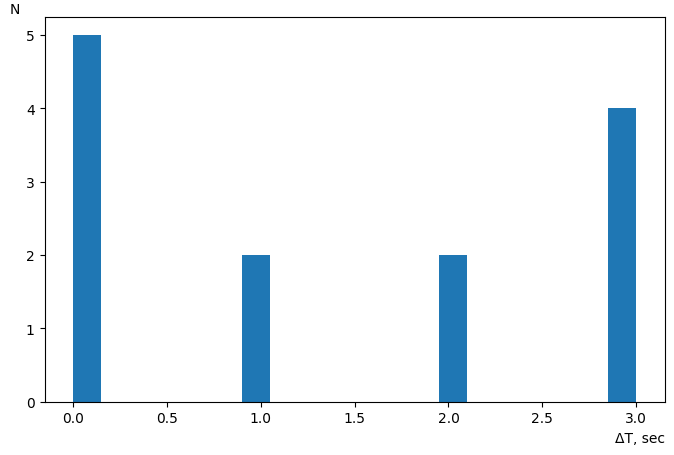

<Figure size 1500x1000 with 0 Axes>

In [ ]:
path_to_file = 'data/sample_29.csv'

data = make_data_ecg3(pd.read_csv('sample_29.csv')['X'].values)
fig, ax = plt.subplots(figsize=(30,10))
ax.set_ylabel('X', rotation='horizontal', loc='top', fontsize =15)
ax.set_xlabel('T, sec', loc='right', fontsize=15)
ax.plot(data, color = 'blue')
ax.grid()
k = min(data)/np.pi
k1 = max(data)/np.pi
plt.yticks(np.arange(int(k)*np.pi, (int(k1)+1)*np.pi, np.pi))
ax.set_xticks([ i for i in range(200,len(data),200)])
l = []
labs = []
for i in range(int(k),int(k1)+1):
    l.append(i*np.pi)
    if i == 0:
        labs.append('0')
    elif i == -1:
        labs.append(r'-$\pi$')
    elif i == 1:
        labs.append(r'$\pi$')
    else:
        labs.append(str(i) + r'$\pi$' )


plt.yticks(l,labs)
plt.ylim(ymin=(int(k)-1)*np.pi)
plt.xlim(0)



ax.set_xticks([ i for i in range(200,len(data),200)])
plt.xlim(0)

plt.show()

#plt.savefig('graphs/sample29_3.pdf')
#pdf = matplotlib.backends.backend_pdf.PdfPages("graphs/sample29_3.pdf")
#pdf.savefig( fig )
#pdf.close()



print('ECG: Plot #4')

bp = Binary_Telegraph_Process(length, None, 'ECG', RANDOM_SEED=[2])
deltas = get_deltas(bp.clusters())

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(list(deltas), 20)
plt.xlabel('ΔT, sec', loc = 'right')
plt.ylabel('N', loc='top', rotation = 'horizontal')
plt.figure(figsize = (15,10))

#plt.savefig('graphs/sample29_4.pdf')
#pdf = matplotlib.backends.backend_pdf.PdfPages("graphs/sample29_4.pdf")

#pdf.savefig( fig )
#pdf.close()

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model

Plot #2


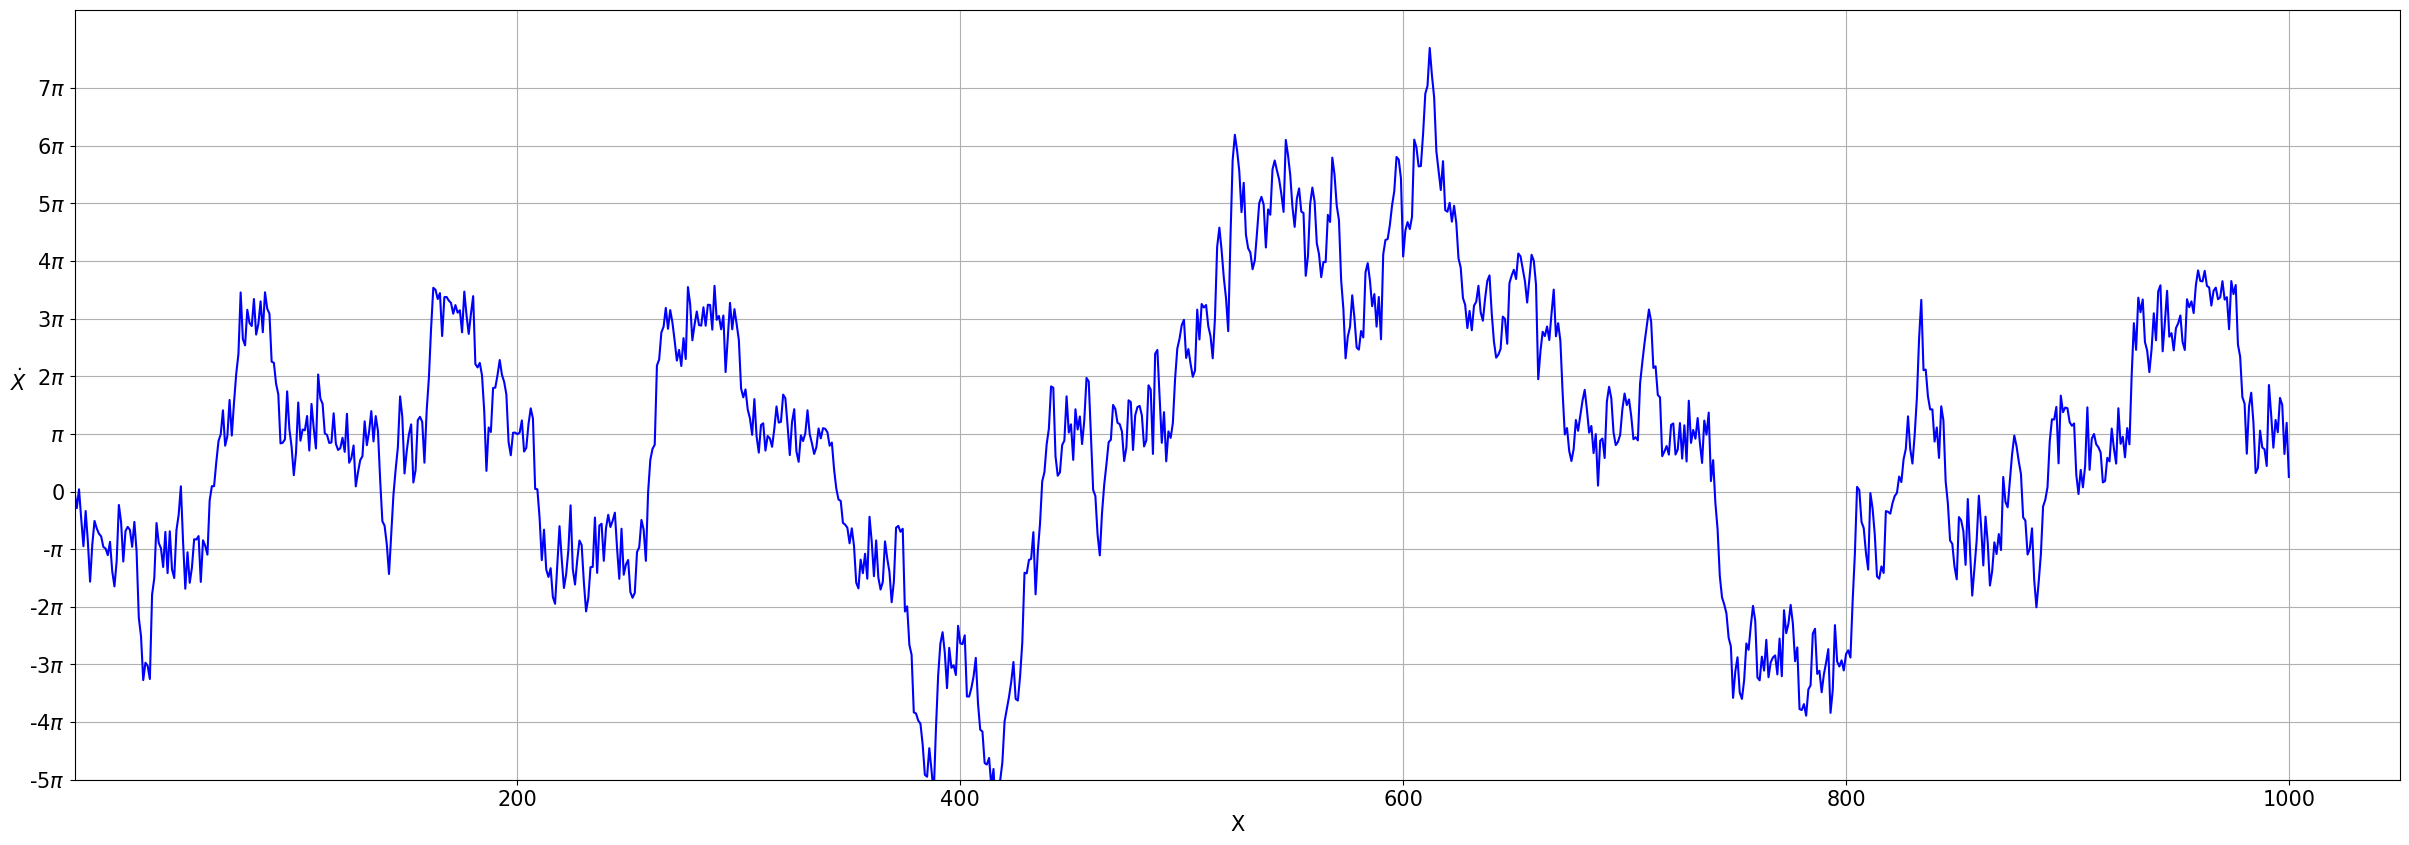

In [ ]:
print('Plot #2')

bp = Binary_Telegraph_Process(length, np.random.normal, 0, 1, RANDOM_SEED=[22])

fig = plot_ax(bp.get_data(), length)

#plt.legend(loc = 'upper right', fontsize = 18)
plt.xticks(fontsize= 15)
plt.yticks(fontsize= 15)
plt.xlabel('X')
plt.ylabel(r'$\dot{X}$')

plt.savefig('plot_2.pdf')
pdf = matplotlib.backends.backend_pdf.PdfPages("plot_2.pdf")

pdf.savefig( fig )
pdf.close()
plt.show()

In [ ]:
t_c

,trans_type,path,data_pi,levels,sinx,errors
0,0,0,0.000000,0,0.000003,0.000000
1,0,[0.06914818938813362],-0.069148,0,-0.215531,-0.217242
2,0,[0.3999303348993383],0.330782,0,0.861990,1.471949
3,0,[0.02368100891554814],0.307101,0,0.821927,-0.936386
4,0,[0.14150049291801386],0.448602,0,0.986992,-0.377391
...,...,...,...,...,...,...
99996,0,[0.3250549786995478],-45.093886,-45,0.290694,0.053440
99997,0,[0.30500952083755806],-45.398896,-45,0.949979,-1.248909
99998,0,[0.31920321568647836],-45.079692,-45,0.247754,0.052828
99999,0,[0.2981043363353706],-45.377797,-45,0.927206,-1.184276


In [ ]:
t_c['lagged_col1'] = t_c['data_pi'].shift(1)
t_c

,trans_type,path,data_pi,levels,sinx,errors,lagged_col1
0,0,0,0.000000,0,0.000003,0.000000,NaN
1,0,[0.06914818938813362],-0.069148,0,-0.215531,-0.217242,0.000000
2,0,[0.3999303348993383],0.330782,0,0.861990,1.471949,-0.069148
3,0,[0.02368100891554814],0.307101,0,0.821927,-0.936386,0.330782
4,0,[0.14150049291801386],0.448602,0,0.986992,-0.377391,0.307101
...,...,...,...,...,...,...,...
99996,0,[0.3250549786995478],-45.093886,-45,0.290694,0.053440,-45.418941
99997,0,[0.30500952083755806],-45.398896,-45,0.949979,-1.248909,-45.093886
99998,0,[0.31920321568647836],-45.079692,-45,0.247754,0.052828,-45.398896
99999,0,[0.2981043363353706],-45.377797,-45,0.927206,-1.184276,-45.079692


In [ ]:
t_c['lagged_col1'].fillna(0, inplace=True)

In [ ]:
indic = [0]

for i in range(1, len(t_c)):
  if t_c['levels'][i] == t_c['levels'][i-1]:
    indic.append(0)
  else:
    indic.append(1)

In [ ]:
len(indic)

100001

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.models import Model

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import confusion_matrix

n = 100001

# define the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(len(t_c['lagged_col1']), 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# prepare the training data

split_ratio = 0.7
split_index = int(len(t_c['data_pi']) * split_ratio)

train_X= t_c['lagged_col1'][:split_index]
train_Y = indic[:split_index]

test_X= t_c['lagged_col1'][split_index:]
test_Y = indic[split_index:]

train_X = np.array(train_X).reshape(len(train_X), 1, 1)
train_Y = np.array(train_Y)

test_X = np.array(test_X).reshape(len(test_X), 1, 1)
test_Y = np.array(test_Y)


# Train the model
model.fit(train_X, n, epochs=100, batch_size=1, verbose=2)

# Test the model
testPredict = model.predict(test_X)
testPredict = np.round(testPredict) # round predictions to 0 or 1
testLabels = np.round(test_Y)

tn, fp, fn, tp = confusion_matrix(testLabels, testPredict).ravel()
conf_matrix = np.array([[tp, fp], [fn, tn]])
print(conf_matrix)

ValueError: ignored

In [ ]:

split_ratio = 0.7
split_index = int(len(t_c['data_pi']) * split_ratio)

train_X= t_c['lagged_col1'][:split_index]
train_Y = indic[:split_index]

test_X= t_c['lagged_col1'][split_index:]
test_Y = indic[split_index:]

train_X = np.array(train_X).reshape(len(train_X), 1, 1)
train_Y = np.array(train_Y)

test_X = np.array(test_X).reshape(len(test_X), 1, 1)
test_Y = np.array(test_Y)

In [ ]:
train_X= t_c['lagged_col1'][:split_index]
np.array(train_X)

array([  0.        ,   0.        ,  -0.06914819, ..., -63.14202152,
       -62.46707289, -62.8221214 ])

In [ ]:
split_ratio = 0.7
split_index = int(len(t_c['data_pi']) * split_ratio)
train_data = t_c['data_pi'][:split_index]
train_labels = t_c['levels'][:split_index]
test_data = pd.DataFrame(np.array(test_data) , columns = ['data_pi'])
test_labels = pd.DataFrame(np.array(test_labels) , columns = ['levels'])

In [ ]:
test_data1 = test_data
test_data1

,data_pi
0,-63.469560
1,-62.764474
2,-63.205066
3,-62.630263
4,-62.298240
...,...
29996,-45.093886
29997,-45.398896
29998,-45.079692
29999,-45.377797


In [ ]:
split_ratio = 0.7
split_index = int(len(t_c['data_pi']) * split_ratio)
train_data = t_c['data_pi'][:split_index]
train_labels = t_c['levels'][:split_index]
test_data = pd.DataFrame(np.array(test_data) , columns = ['data_pi'])
test_labels = pd.DataFrame(np.array(test_labels) , columns = ['levels'])

# Convert data to array of arrays with look_back time steps
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        #print(len(dataset))
        a = dataset[i:(i+look_back-1)]
        dataX.append(a)
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

look_back = 5 # number of time steps to look back
trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data['data_pi'], look_back)

# Define LSTM model
model = tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(4, input_shape=(look_back, 1)))
model.add(tf.keras.layers.Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')



ValueError: ignored

In [ ]:
trainX = trainX.reshape(279976, 1)

In [23]:
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

# Test the model
testPredict = model.predict(testX)
testPredict = np.round(testPredict) # round predictions to 0 or 1
testLabels = np.round(testY)

# Create confusion matrix
tn, fp, fn, tp = confusion_matrix(testLabels, testPredict).ravel()
conf_matrix = np.array([[tp, fp], [fn, tn]])
print(conf_matrix)

NameError: name 'model' is not defined